In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Carga de csvs para exploración

df_universo  = pd.read_csv('data/universo.csv')

In [127]:
df_base_clientes  = pd.read_csv('data/base_clientes.csv')
df_base_saldos_cuentas  = pd.read_csv('data/base_saldos_cuentas.csv')

In [128]:
df_universo.head()

,ID,target,periodo
0,4d5a33701cb5b30b0b0a924d80de4ae78fbd0b54e2117f...,0,period_5
1,bf7092e5f394d266143dfe90b3fc73eac51f0b0084d7a3...,0,period_5
2,270d8f8f607d19886c50edb7746c3670194134b56d31e2...,0,period_5
3,5e6b7bea5e4911329669f45728d3398ad54dfe11fbb16d...,0,period_5
4,98954adf775b9fce1c9e311a025ec3e0a1c6e90f991ef7...,0,period_5


In [129]:
df_universo.shape

(535943, 3)

In [130]:
df_universo['target'].value_counts()

target
0    464075
1     47171
5      8489
4      6893
2      5929
3      3386
Name: count, dtype: int64

In [131]:
df_universo['target'].value_counts(normalize=True).sort_index() * 100

target
0    86.590365
1     8.801496
2     1.106274
3     0.631784
4     1.286144
5     1.583937
Name: proportion, dtype: float64

In [132]:
df_universo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 535943 entries, 0 to 535942
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   ID       535943 non-null  object
 1   target   535943 non-null  int64 
 2   periodo  535943 non-null  object
dtypes: int64(1), object(2)
memory usage: 12.3+ MB


In [133]:
df_universo['target'].describe()

count    535943.000000
mean          0.259737
std           0.850548
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           5.000000
Name: target, dtype: float64

In [134]:
df_universo.isnull().sum()


ID         0
target     0
periodo    0
dtype: int64

In [135]:
df_universo['periodo'].nunique()


6

**BASE CLIENTES**

In [136]:
df_base_clientes.head()

,ID,edad,ingreso,anios_exp,tipo_empleo,buro_de_credito,pago_nomina,tc,prest_per,prest_veh_hip,cuenta_ahorro,ofer_prest_per,ofer_tc,ofer_compra_deuda
0,42af3bf64c2c14307361e970e76c9653df78b215838971...,4.2484,4.1259,0.0,type_2,category_4,4.8095,Yes,No,No,Yes,No,No,No
1,5ab9acd6dc30e0e9361ca53e797b40f68841bd698d0926...,4.6903,3.9570,0.0,type_7,category_9,0.0000,No,No,No,Yes,No,No,No
2,8e40f988dd93417a0a40c32e65386425d891c879fedf4c...,4.1682,4.4640,0.0,type_7,category_5,0.0000,No,No,No,Yes,No,No,No
3,0e48974ce6e81d9e81a8da780521a2f98fb2385dc879df...,3.9651,4.0966,0.0,type_7,category_3,0.0000,Yes,Yes,Yes,Yes,No,No,No
4,e033c53b4fb230de5da6868503a9e079b289e064d62de4...,3.9576,4.1876,0.0,type_7,category_5,0.0000,Yes,No,No,Yes,No,No,No


In [137]:
df_base_clientes.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 809579 entries, 0 to 809578
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ID                 809579 non-null  object 
 1   edad               809579 non-null  float64
 2   ingreso            809579 non-null  float64
 3   anios_exp          809579 non-null  float64
 4   tipo_empleo        809579 non-null  object 
 5   buro_de_credito    809579 non-null  object 
 6   pago_nomina        809579 non-null  float64
 7   tc                 809579 non-null  object 
 8   prest_per          809579 non-null  object 
 9   prest_veh_hip      809579 non-null  object 
 10  cuenta_ahorro      809579 non-null  object 
 11  ofer_prest_per     809579 non-null  object 
 12  ofer_tc            809579 non-null  object 
 13  ofer_compra_deuda  809579 non-null  object 
dtypes: float64(4), object(10)
memory usage: 86.5+ MB


In [138]:
df_base_clientes.describe()


,edad,ingreso,anios_exp,pago_nomina
count,809579.000000,809579.000000,809579.000000,809579.000000
mean,4.275201,4.284237,1.333632,1.417533
std,0.377544,0.477204,1.946502,2.017392
min,0.000000,0.000000,0.000000,0.000000
25%,4.001100,4.098200,0.000000,0.000000
50%,4.266700,4.286900,0.000000,0.000000
75%,4.549500,4.509800,3.619300,3.973700
max,5.000000,5.000000,5.000000,5.000000


In [139]:
df_base_clientes.duplicated().sum() 


np.int64(0)

In [140]:
df_base_clientes.isnull().sum()


ID                   0
edad                 0
ingreso              0
anios_exp            0
tipo_empleo          0
buro_de_credito      0
pago_nomina          0
tc                   0
prest_per            0
prest_veh_hip        0
cuenta_ahorro        0
ofer_prest_per       0
ofer_tc              0
ofer_compra_deuda    0
dtype: int64

In [141]:
df_base_clientes.shape

(809579, 14)

In [142]:

df_base_clientes['der_ingreso_por_anio_exp'] = df_base_clientes['ingreso'] / (df_base_clientes['anios_exp'] + 1)
df_base_clientes['der_edad_laboral_relativa'] = df_base_clientes['anios_exp'] / (df_base_clientes['edad'] + 1)
df_base_clientes['der_edad_ingreso_relativa'] = df_base_clientes['ingreso'] / (df_base_clientes['edad'] + 1)
df_base_clientes['der_edad_anios_exp'] = df_base_clientes['edad'] / (df_base_clientes['anios_exp'] + 1)
df_base_clientes['der_ingreso_edad_exp'] = df_base_clientes['ingreso'] / ((df_base_clientes['edad'] + 1) * (df_base_clientes['anios_exp'] + 1))
df_base_clientes['der_ingreso_vs_nomina'] = df_base_clientes['pago_nomina'] / (df_base_clientes['ingreso'] + 1)
df_base_clientes['der_nomina_vs_exp'] = df_base_clientes['pago_nomina'] / (df_base_clientes['anios_exp'] + 1)
df_base_clientes['der_ingreso_nomina_ratio'] = (df_base_clientes['ingreso'] - df_base_clientes['pago_nomina']) / (df_base_clientes['ingreso'] + 1)
df_base_clientes['num_productos'] = (
    (df_base_clientes['tc'] == 'Yes').astype(int) +
    (df_base_clientes['prest_per'] == 'Yes').astype(int) +
    (df_base_clientes['prest_veh_hip'] == 'Yes').astype(int) +
    (df_base_clientes['cuenta_ahorro'] == 'Yes').astype(int)
)

df_base_clientes['num_ofertas'] = (
    (df_base_clientes['ofer_prest_per'] == 'Yes').astype(int) +
    (df_base_clientes['ofer_tc'] == 'Yes').astype(int) +
    (df_base_clientes['ofer_compra_deuda'] == 'Yes').astype(int)
)

df_base_clientes['relacion_ofertas_uso'] = df_base_clientes['num_productos'] / (df_base_clientes['num_ofertas'] + 1)

df_base_clientes['usa_tc_y_ahorro'] = ((df_base_clientes['tc'] == 'Yes') & (df_base_clientes['cuenta_ahorro'] == 'Yes')).astype(int)
df_base_clientes['usa_prestamo_y_tc'] = ((df_base_clientes['prest_per'] == 'Yes') & (df_base_clientes['tc'] == 'Yes')).astype(int)
df_base_clientes['tiene_creditos_multiples'] = ((df_base_clientes['prest_per'] == 'Yes') & (df_base_clientes['prest_veh_hip'] == 'Yes')).astype(int)

df_base_clientes['oferta_credito_activo'] = ((df_base_clientes['ofer_prest_per'] == 'Yes') | (df_base_clientes['ofer_tc'] == 'Yes')).astype(int)
df_base_clientes['oferta_total_vs_uso'] = df_base_clientes['num_ofertas'] / (df_base_clientes['num_productos'] + 1)

df_base_clientes['riesgo_credito_grupo'] = df_base_clientes['buro_de_credito'].map({'category_1': 1, 'category_2': 2, 'category_3': 3, 'category_4': 4, 'category_5': 5, 'category_6': 6, 'category_7': 7, 'category_8': 8, 'category_9': 9})


df_base_clientes['log_ingreso'] = np.log1p(df_base_clientes['ingreso'])
df_base_clientes['ingreso_sq'] = df_base_clientes['ingreso'] ** 2
df_base_clientes['ingreso_per_producto'] = df_base_clientes['ingreso'] / (df_base_clientes['num_productos'] + 1e-6)
df_base_clientes['ratio_nomina_ingreso_log'] = np.log1p((df_base_clientes['pago_nomina'] + 1e-6) / (df_base_clientes['ingreso'] + 1e-6))


In [143]:
df_base_clientes_prefixed = df_base_clientes.rename(
    columns={col: f"DB_CLI_{col}" for col in df_base_clientes.columns if col != 'ID'}
)

# 1. Primer merge
df_universo = df_universo.merge(
    df_base_clientes_prefixed,
    on='ID',
    how='left'
)

In [144]:
print(df_universo.shape)
df_universo.head()

(535943, 37)


,ID,target,periodo,DB_CLI_edad,DB_CLI_ingreso,DB_CLI_anios_exp,DB_CLI_tipo_empleo,DB_CLI_buro_de_credito,DB_CLI_pago_nomina,DB_CLI_tc,...,DB_CLI_usa_tc_y_ahorro,DB_CLI_usa_prestamo_y_tc,DB_CLI_tiene_creditos_multiples,DB_CLI_oferta_credito_activo,DB_CLI_oferta_total_vs_uso,DB_CLI_riesgo_credito_grupo,DB_CLI_log_ingreso,DB_CLI_ingreso_sq,DB_CLI_ingreso_per_producto,DB_CLI_ratio_nomina_ingreso_log
0,4d5a33701cb5b30b0b0a924d80de4ae78fbd0b54e2117f...,0,period_5,3.8498,4.6527,0.000,type_2,category_6,0.0,No,...,0,0,0,0,0.0,6,1.732133,21.647617,4.652695,2.149289e-07
1,bf7092e5f394d266143dfe90b3fc73eac51f0b0084d7a3...,0,period_5,4.5476,4.2447,4.274,type_3,category_4,0.0,No,...,0,0,0,0,0.0,4,1.657218,18.017478,4.244696,2.355878e-07
2,270d8f8f607d19886c50edb7746c3670194134b56d31e2...,0,period_5,4.3600,4.2117,0.000,type_2,category_9,0.0,No,...,0,0,0,0,0.0,9,1.650906,17.738417,4.211696,2.374337e-07
3,5e6b7bea5e4911329669f45728d3398ad54dfe11fbb16d...,0,period_5,4.3914,4.1584,0.000,type_7,category_2,0.0,No,...,0,0,0,1,1.0,2,1.640626,17.292291,4.158396,2.404770e-07
4,98954adf775b9fce1c9e311a025ec3e0a1c6e90f991ef7...,0,period_5,4.3077,4.3285,0.000,type_2,category_6,0.0,No,...,0,0,0,0,0.0,6,1.673070,18.735912,4.328496,2.310268e-07


**df_base_saldos_cuentas**

In [145]:
df_base_saldos_cuentas.head()

,mes,ID,saldo_ahorros,saldo_otros,periodo
0,11,c7a6cecac361a970ee6c7cb9f2679c38c668940c6ebdc5...,4.1900,0.0,period_5
1,12,68f89dc7efe7cd1ce3cf6d52d8867bd2b84f236736bf91...,4.4621,0.0,period_5
2,2,e3f6afb18792d0b97cb9a63ad9567bbd106146c78d212a...,4.2878,0.0,period_5
3,1,8993170400939d522bdc72707527f5ab90202119fe3cab...,5.0000,5.0,period_5
4,7,399d686897232a55c713d61a6bdc7e232ab85b864d6288...,3.8922,0.0,period_5


In [146]:
df_base_saldos_cuentas.head()


,mes,ID,saldo_ahorros,saldo_otros,periodo
0,11,c7a6cecac361a970ee6c7cb9f2679c38c668940c6ebdc5...,4.1900,0.0,period_5
1,12,68f89dc7efe7cd1ce3cf6d52d8867bd2b84f236736bf91...,4.4621,0.0,period_5
2,2,e3f6afb18792d0b97cb9a63ad9567bbd106146c78d212a...,4.2878,0.0,period_5
3,1,8993170400939d522bdc72707527f5ab90202119fe3cab...,5.0000,5.0,period_5
4,7,399d686897232a55c713d61a6bdc7e232ab85b864d6288...,3.8922,0.0,period_5


In [147]:
df_base_saldos_cuentas.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8876560 entries, 0 to 8876559
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   mes            int64  
 1   ID             object 
 2   saldo_ahorros  float64
 3   saldo_otros    float64
 4   periodo        object 
dtypes: float64(2), int64(1), object(2)
memory usage: 338.6+ MB


In [148]:
df_base_saldos_cuentas.describe()


,mes,saldo_ahorros,saldo_otros
count,8.876560e+06,8.876560e+06,8.876560e+06
mean,6.632422e+00,3.140673e+00,6.191672e-01
std,3.448429e+00,1.207045e+00,1.405347e+00
min,1.000000e+00,0.000000e+00,0.000000e+00
25%,4.000000e+00,2.644100e+00,0.000000e+00
50%,7.000000e+00,3.318500e+00,0.000000e+00
75%,1.000000e+01,3.986700e+00,0.000000e+00
max,1.200000e+01,5.000000e+00,5.000000e+00


In [149]:
import pandas as pd
from functools import reduce

# -------------------------------------------------------------
# ORDEN Y CONFIGURACIÓN BASE
# -------------------------------------------------------------
df_base_saldos_cuentas = df_base_saldos_cuentas.sort_values(by=['ID', 'mes'], ascending=[True, False])

# Detectar el mes máximo disponible 
mes_max = df_base_saldos_cuentas['mes'].max()

# -------------------------------------------------------------
# FUNCIÓN PARA AGREGAR LOS ÚLTIMOS n MESES
# -------------------------------------------------------------
def agregar_por_meses(df, n, mes_max):
    """
    Calcula agregados de saldo de ahorros (max, min, sum, mean)
    para los últimos n meses de cada cliente.
    """
    meses = list(range(mes_max, mes_max - n, -1))  # Ejemplo: si mes_max=12, n=3 → [12,11,10]
    sufijo = f"{n}_meses"
    
    return (
        df[df['mes'].isin(meses)]
        .groupby('ID', as_index=False)
        .agg(
            **{
                f"{sufijo}_max_saldo_ahorros": ('saldo_ahorros', 'max'),
                f"{sufijo}_min_saldo_ahorros": ('saldo_ahorros', 'min'),
                f"{sufijo}_sum_saldo_ahorros": ('saldo_ahorros', 'sum'),
                f"{sufijo}_prom_saldo_ahorros": ('saldo_ahorros', 'mean'),
            }
        )
    )

# -------------------------------------------------------------
# GENERACIÓN AUTOMÁTICA DE AGREGADOS (2 A 12 MESES)
# -------------------------------------------------------------
agregados_list = [
    agregar_por_meses(df_base_saldos_cuentas, n, mes_max)
    for n in range(2, 13)
]

# -------------------------------------------------------------
# UNIÓN FINAL DE TODOS LOS AGREGADOS POR ID
# -------------------------------------------------------------
df_agregados_base_saldos_cuentas = reduce(
    lambda left, right: pd.merge(left, right, on='ID', how='left'),
    agregados_list
)

# -------------------------------------------------------------
# REVISIÓN FINAL
# -------------------------------------------------------------
print(f"Shape final: {df_agregados_base_saldos_cuentas.shape}")
df_agregados_base_saldos_cuentas.head()


Shape final: (784556, 45)


,ID,2_meses_max_saldo_ahorros,2_meses_min_saldo_ahorros,2_meses_sum_saldo_ahorros,2_meses_prom_saldo_ahorros,3_meses_max_saldo_ahorros,3_meses_min_saldo_ahorros,3_meses_sum_saldo_ahorros,3_meses_prom_saldo_ahorros,4_meses_max_saldo_ahorros,...,10_meses_sum_saldo_ahorros,10_meses_prom_saldo_ahorros,11_meses_max_saldo_ahorros,11_meses_min_saldo_ahorros,11_meses_sum_saldo_ahorros,11_meses_prom_saldo_ahorros,12_meses_max_saldo_ahorros,12_meses_min_saldo_ahorros,12_meses_sum_saldo_ahorros,12_meses_prom_saldo_ahorros
0,00000f6dd2df6f081ce59cc4490f152e3fd5695de62bd9...,2.0478,1.9315,3.9793,1.98965,3.2484,1.9315,7.2277,2.409233,3.4815,...,15.7029,1.57029,3.4815,0.4939,16.2953,1.481391,3.4815,0.4939,16.8877,1.407308
1,000043cc1abd7597c99f494cc523ff99a4e0e64e98b128...,3.5701,2.7086,6.2787,3.13935,3.5701,2.7086,9.1865,3.062167,3.5701,...,33.4863,3.34863,3.9980,2.6010,36.0873,3.280664,3.9980,2.3428,38.4301,3.202508
2,000095b7b77ff622b2130f2d4bfa1e8d81f1fc4580a248...,3.9865,3.9865,7.9730,3.98650,3.9865,3.9865,11.9595,3.986500,3.9865,...,39.8650,3.98650,3.9865,3.9865,43.8515,3.986500,3.9865,3.9865,47.8380,3.986500
3,00009bb00e84af44d1abc86b9fbd155842ffef6cad814d...,4.0610,4.0464,8.1074,4.05370,4.0791,4.0464,12.1865,4.062167,4.0946,...,42.1374,4.21374,4.3968,4.0464,46.4952,4.226836,4.3968,4.0464,50.7124,4.226033
4,0000a9728fc57abef25c2fc0424c9c907a5559e7b8b559...,3.9150,2.8720,6.7870,3.39350,3.9150,2.8720,9.6760,3.225333,3.9150,...,27.7544,2.77544,3.9150,2.0286,30.7387,2.794427,3.9150,2.0286,33.7255,2.810458


In [150]:
# -------------------------------------------------------------
# CREAR NUEVOS AGREGADOS ROLLING
# -------------------------------------------------------------
df_agregados_roll = df_base_saldos_cuentas.groupby('ID', as_index=False).agg(
    std_3m_ahorros=('saldo_ahorros', lambda x: x.rolling(3, min_periods=1).std().iloc[-1]),
    cv_3m_ahorros=('saldo_ahorros', lambda x: (x.rolling(3, min_periods=1).std() / (x.rolling(3, min_periods=1).mean() + 1e-6)).iloc[-1])
)

# -------------------------------------------------------------
# UNIÓN CON LOS AGREGADOS ANTERIORES
# -------------------------------------------------------------
df_agregados_base_saldos_cuentas = pd.merge(
    df_agregados_base_saldos_cuentas,
    df_agregados_roll,
    on='ID',
    how='left'
)

# -------------------------------------------------------------
# REVISIÓN FINAL
# -------------------------------------------------------------
print(f"Shape final: {df_agregados_base_saldos_cuentas.shape}")
df_agregados_base_saldos_cuentas.head()

Shape final: (784556, 47)


,ID,2_meses_max_saldo_ahorros,2_meses_min_saldo_ahorros,2_meses_sum_saldo_ahorros,2_meses_prom_saldo_ahorros,3_meses_max_saldo_ahorros,3_meses_min_saldo_ahorros,3_meses_sum_saldo_ahorros,3_meses_prom_saldo_ahorros,4_meses_max_saldo_ahorros,...,11_meses_max_saldo_ahorros,11_meses_min_saldo_ahorros,11_meses_sum_saldo_ahorros,11_meses_prom_saldo_ahorros,12_meses_max_saldo_ahorros,12_meses_min_saldo_ahorros,12_meses_sum_saldo_ahorros,12_meses_prom_saldo_ahorros,std_3m_ahorros,cv_3m_ahorros
0,00000f6dd2df6f081ce59cc4490f152e3fd5695de62bd9...,2.0478,1.9315,3.9793,1.98965,3.2484,1.9315,7.2277,2.409233,3.4815,...,3.4815,0.4939,16.2953,1.481391,3.4815,0.4939,16.8877,1.407308,0.535319,0.593831
1,000043cc1abd7597c99f494cc523ff99a4e0e64e98b128...,3.5701,2.7086,6.2787,3.13935,3.5701,2.7086,9.1865,3.062167,3.5701,...,3.9980,2.6010,36.0873,3.280664,3.9980,2.3428,38.4301,3.202508,0.700319,0.244073
2,000095b7b77ff622b2130f2d4bfa1e8d81f1fc4580a248...,3.9865,3.9865,7.9730,3.98650,3.9865,3.9865,11.9595,3.986500,3.9865,...,3.9865,3.9865,43.8515,3.986500,3.9865,3.9865,47.8380,3.986500,0.000000,0.000000
3,00009bb00e84af44d1abc86b9fbd155842ffef6cad814d...,4.0610,4.0464,8.1074,4.05370,4.0791,4.0464,12.1865,4.062167,4.0946,...,4.3968,4.0464,46.4952,4.226836,4.3968,4.0464,50.7124,4.226033,0.094468,0.021848
4,0000a9728fc57abef25c2fc0424c9c907a5559e7b8b559...,3.9150,2.8720,6.7870,3.39350,3.9150,2.8720,9.6760,3.225333,3.9150,...,3.9150,2.0286,30.7387,2.794427,3.9150,2.0286,33.7255,2.810458,0.021427,0.007207


In [151]:
df_base_saldos_cuentas['ratio_ahorros_otros'] = (
    df_base_saldos_cuentas['saldo_ahorros'] /
    (df_base_saldos_cuentas['saldo_otros'] + 1e-6)
)

df_base_saldos_cuentas['prop_ahorros_total'] = (
    df_base_saldos_cuentas['saldo_ahorros'] /
    (df_base_saldos_cuentas['saldo_ahorros'] + df_base_saldos_cuentas['saldo_otros'] + 1e-6)
)

# -------------------------------------------------------------
# FILTRAR SOLO MES 12
# -------------------------------------------------------------
df_mes12 = df_base_saldos_cuentas[df_base_saldos_cuentas['mes'] == 12]

# -------------------------------------------------------------
# CREAR NUEVOS AGREGADOS POR ID
# -------------------------------------------------------------
df_agregados_ratio = df_mes12.groupby('ID', as_index=False).agg(
    ratio_ahorros_otros=('ratio_ahorros_otros', 'first'),
    prop_ahorros_total=('prop_ahorros_total', 'first')
)

# -------------------------------------------------------------
# UNIÓN CON LOS AGREGADOS ANTERIORES
# -------------------------------------------------------------
df_agregados_base_saldos_cuentas = pd.merge(
    df_agregados_base_saldos_cuentas,
    df_agregados_ratio,
    on='ID',
    how='left'
)

# -------------------------------------------------------------
# REVISIÓN FINAL
# -------------------------------------------------------------
print(f"Shape final: {df_agregados_base_saldos_cuentas.shape}")
df_agregados_base_saldos_cuentas.head()

Shape final: (784556, 49)


,ID,2_meses_max_saldo_ahorros,2_meses_min_saldo_ahorros,2_meses_sum_saldo_ahorros,2_meses_prom_saldo_ahorros,3_meses_max_saldo_ahorros,3_meses_min_saldo_ahorros,3_meses_sum_saldo_ahorros,3_meses_prom_saldo_ahorros,4_meses_max_saldo_ahorros,...,11_meses_sum_saldo_ahorros,11_meses_prom_saldo_ahorros,12_meses_max_saldo_ahorros,12_meses_min_saldo_ahorros,12_meses_sum_saldo_ahorros,12_meses_prom_saldo_ahorros,std_3m_ahorros,cv_3m_ahorros,ratio_ahorros_otros,prop_ahorros_total
0,00000f6dd2df6f081ce59cc4490f152e3fd5695de62bd9...,2.0478,1.9315,3.9793,1.98965,3.2484,1.9315,7.2277,2.409233,3.4815,...,16.2953,1.481391,3.4815,0.4939,16.8877,1.407308,0.535319,0.593831,1.931500e+06,0.999999
1,000043cc1abd7597c99f494cc523ff99a4e0e64e98b128...,3.5701,2.7086,6.2787,3.13935,3.5701,2.7086,9.1865,3.062167,3.5701,...,36.0873,3.280664,3.9980,2.3428,38.4301,3.202508,0.700319,0.244073,3.176217e+01,0.969477
2,000095b7b77ff622b2130f2d4bfa1e8d81f1fc4580a248...,3.9865,3.9865,7.9730,3.98650,3.9865,3.9865,11.9595,3.986500,3.9865,...,43.8515,3.986500,3.9865,3.9865,47.8380,3.986500,0.000000,0.000000,3.986500e+06,1.000000
3,00009bb00e84af44d1abc86b9fbd155842ffef6cad814d...,4.0610,4.0464,8.1074,4.05370,4.0791,4.0464,12.1865,4.062167,4.0946,...,46.4952,4.226836,4.3968,4.0464,50.7124,4.226033,0.094468,0.021848,4.046400e+06,1.000000
4,0000a9728fc57abef25c2fc0424c9c907a5559e7b8b559...,3.9150,2.8720,6.7870,3.39350,3.9150,2.8720,9.6760,3.225333,3.9150,...,30.7387,2.794427,3.9150,2.0286,33.7255,2.810458,0.021427,0.007207,3.915000e+06,1.000000


In [152]:
# Mes con mayor saldo
df_mes_max = (
    df_base_saldos_cuentas.groupby('ID')['saldo_ahorros']
    .idxmax().reset_index(name='mes_max_saldo')
)

# Mes con menor saldo
df_mes_min = (
    df_base_saldos_cuentas.groupby('ID')['saldo_ahorros']
    .idxmin().reset_index(name='mes_min_saldo')
)

# Número de meses consecutivos con caída de saldo
def meses_caida(x):
    return (x.diff() < 0).astype(int).rolling(3, min_periods=1).sum().iloc[-1]

df_caida = (
    df_base_saldos_cuentas.groupby('ID')['saldo_ahorros']
    .apply(meses_caida).reset_index(name='meses_caida_consecutiva')
)

# Unión con df_mes_max
df_agregados_base_saldos_cuentas = pd.merge(
    df_agregados_base_saldos_cuentas,
    df_mes_max,
    on='ID',
    how='left'
)

# Unión con df_mes_min
df_agregados_base_saldos_cuentas = pd.merge(
    df_agregados_base_saldos_cuentas,
    df_mes_min,
    on='ID',
    how='left'
)

# Unión con df_caida
df_agregados_base_saldos_cuentas = pd.merge(
    df_agregados_base_saldos_cuentas,
    df_caida,
    on='ID',
    how='left'
)

# Revisión final
print(f"Shape final: {df_agregados_base_saldos_cuentas.shape}")
df_agregados_base_saldos_cuentas.head()

Shape final: (784556, 52)


,ID,2_meses_max_saldo_ahorros,2_meses_min_saldo_ahorros,2_meses_sum_saldo_ahorros,2_meses_prom_saldo_ahorros,3_meses_max_saldo_ahorros,3_meses_min_saldo_ahorros,3_meses_sum_saldo_ahorros,3_meses_prom_saldo_ahorros,4_meses_max_saldo_ahorros,...,12_meses_min_saldo_ahorros,12_meses_sum_saldo_ahorros,12_meses_prom_saldo_ahorros,std_3m_ahorros,cv_3m_ahorros,ratio_ahorros_otros,prop_ahorros_total,mes_max_saldo,mes_min_saldo,meses_caida_consecutiva
0,00000f6dd2df6f081ce59cc4490f152e3fd5695de62bd9...,2.0478,1.9315,3.9793,1.98965,3.2484,1.9315,7.2277,2.409233,3.4815,...,0.4939,16.8877,1.407308,0.535319,0.593831,1.931500e+06,0.999999,6574850,2043247,1.0
1,000043cc1abd7597c99f494cc523ff99a4e0e64e98b128...,3.5701,2.7086,6.2787,3.13935,3.5701,2.7086,9.1865,3.062167,3.5701,...,2.3428,38.4301,3.202508,0.700319,0.244073,3.176217e+01,0.969477,5740473,5765000,2.0
2,000095b7b77ff622b2130f2d4bfa1e8d81f1fc4580a248...,3.9865,3.9865,7.9730,3.98650,3.9865,3.9865,11.9595,3.986500,3.9865,...,3.9865,47.8380,3.986500,0.000000,0.000000,3.986500e+06,1.000000,6066155,6066155,0.0
3,00009bb00e84af44d1abc86b9fbd155842ffef6cad814d...,4.0610,4.0464,8.1074,4.05370,4.0791,4.0464,12.1865,4.062167,4.0946,...,4.0464,50.7124,4.226033,0.094468,0.021848,4.046400e+06,1.000000,3447096,1829462,2.0
4,0000a9728fc57abef25c2fc0424c9c907a5559e7b8b559...,3.9150,2.8720,6.7870,3.39350,3.9150,2.8720,9.6760,3.225333,3.9150,...,2.0286,33.7255,2.810458,0.021427,0.007207,3.915000e+06,1.000000,8062034,699660,0.0


In [153]:
df_base_saldos_cuentas_prefixed = df_agregados_base_saldos_cuentas.rename(
    columns={col: f"DB_SAL_CUE_{col}" for col in df_agregados_base_saldos_cuentas.columns if col != 'ID'}
)

In [154]:
df_universo = df_universo.merge(
    df_base_saldos_cuentas_prefixed,
    on='ID',
    how='left'
)

In [155]:
print(df_universo.shape)
df_universo.head()

(535943, 88)


,ID,target,periodo,DB_CLI_edad,DB_CLI_ingreso,DB_CLI_anios_exp,DB_CLI_tipo_empleo,DB_CLI_buro_de_credito,DB_CLI_pago_nomina,DB_CLI_tc,...,DB_SAL_CUE_12_meses_min_saldo_ahorros,DB_SAL_CUE_12_meses_sum_saldo_ahorros,DB_SAL_CUE_12_meses_prom_saldo_ahorros,DB_SAL_CUE_std_3m_ahorros,DB_SAL_CUE_cv_3m_ahorros,DB_SAL_CUE_ratio_ahorros_otros,DB_SAL_CUE_prop_ahorros_total,DB_SAL_CUE_mes_max_saldo,DB_SAL_CUE_mes_min_saldo,DB_SAL_CUE_meses_caida_consecutiva
0,4d5a33701cb5b30b0b0a924d80de4ae78fbd0b54e2117f...,0,period_5,3.8498,4.6527,0.000,type_2,category_6,0.0,No,...,2.5149,39.5354,3.294617,0.894806,0.252333,3175400.0,1.0,7434408.0,3272878.0,1.0
1,bf7092e5f394d266143dfe90b3fc73eac51f0b0084d7a3...,0,period_5,4.5476,4.2447,4.274,type_3,category_4,0.0,No,...,3.2254,40.5731,3.381092,0.003002,0.000844,3225400.0,1.0,316982.0,2007939.0,0.0
2,270d8f8f607d19886c50edb7746c3670194134b56d31e2...,0,period_5,4.3600,4.2117,0.000,type_2,category_9,0.0,No,...,2.7090,42.1470,3.512250,0.005519,0.001410,2753000.0,1.0,4746546.0,546634.0,2.0
3,5e6b7bea5e4911329669f45728d3398ad54dfe11fbb16d...,0,period_5,4.3914,4.1584,0.000,type_7,category_2,0.0,No,...,3.7511,46.6400,3.886667,0.025317,0.006208,3751100.0,1.0,88699.0,3426600.0,2.0
4,98954adf775b9fce1c9e311a025ec3e0a1c6e90f991ef7...,0,period_5,4.3077,4.3285,0.000,type_2,category_6,0.0,No,...,2.6043,35.3925,2.949375,0.124250,0.045243,3408600.0,1.0,1906558.0,5074763.0,2.0


In [156]:
# Hipótesis: El ingreso disponible real es un fuerte predictor.
df_universo['DB_CLI_der_ingreso_disponible'] = df_universo['DB_CLI_ingreso'] - df_universo['DB_CLI_pago_nomina']

# Hipótesis: La proporción del ingreso que queda libre después de la nómina.
df_universo['DB_CLI_der_pct_ingreso_disponible'] = (df_universo['DB_CLI_der_ingreso_disponible']) / (df_universo['DB_CLI_ingreso'] + 1e-6)

# Hipótesis: Interacción entre el ingreso y el riesgo crediticio. Un cliente con altos ingresos
# y mal buró es un perfil de riesgo diferente a uno con bajos ingresos y mal buró.
df_universo['DB_CLI_der_ingreso_por_riesgo'] = df_universo['DB_CLI_ingreso'] / (df_universo['DB_CLI_riesgo_credito_grupo'] + 1e-6)


# --- Características Demográficas y de Ciclo de Vida ---

# Hipótesis: La edad a la que alguien comenzó su carrera puede indicar estabilidad o tipo de profesión.
df_universo['DB_CLI_der_edad_inicio_laboral'] = df_universo['DB_CLI_edad'] - df_universo['DB_CLI_anios_exp']

# Hipótesis: Las variables al cuadrado pueden capturar relaciones no lineales.
df_universo['DB_CLI_der_edad_sq'] = df_universo['DB_CLI_edad'] ** 2
df_universo['DB_CLI_der_anios_exp_sq'] = df_universo['DB_CLI_anios_exp'] ** 2


# --- Comportamiento con Productos y Ofertas ---

# Hipótesis: Identificar si el cliente tiene algún tipo de préstamo activo (personal, vehículo o hipoteca).
df_universo['DB_CLI_der_tiene_algun_prestamo'] = ((df_universo['DB_CLI_prest_per'] == 'Yes') | (df_universo['DB_CLI_prest_veh_hip'] == 'Yes')).astype(int)

# Hipótesis: Relación entre tener un préstamo y tener una cuenta de ahorros.
df_universo['DB_CLI_der_prestamo_y_ahorro'] = ((df_universo['DB_CLI_der_tiene_algun_prestamo'] == 1) & (df_universo['DB_CLI_cuenta_ahorro'] == 'Yes')).astype(int)

# Hipótesis: Un "índice de lealtad" simple: productos que tiene vs. ofertas que recibió.
df_universo['DB_CLI_der_lealtad_ofertas'] = df_universo['DB_CLI_num_productos'] / (df_universo['DB_CLI_num_ofertas'] + 1)


print("Variables de 'base_clientes' creadas.")


# === 2. Propuestas para df_base_saldos_cuentas (Información Histórica) ===

# --- Características de Tendencia y Momentum ---

# Hipótesis: ¿El saldo más reciente es mayor o menor que el promedio del último año? Indica una tendencia reciente.
df_universo['DB_SAL_CUE_der_momento_saldo_12m'] = df_universo['DB_SAL_CUE_12_meses_max_saldo_ahorros'] / (df_universo['DB_SAL_CUE_12_meses_prom_saldo_ahorros'] + 1e-6)
df_universo['DB_SAL_CUE_der_momento_saldo_6m'] = df_universo['DB_SAL_CUE_6_meses_max_saldo_ahorros'] / (df_universo['DB_SAL_CUE_6_meses_prom_saldo_ahorros'] + 1e-6)

# Hipótesis: La diferencia entre el saldo máximo y mínimo en un periodo mide la volatilidad en términos absolutos.
df_universo['DB_SAL_CUE_der_rango_saldo_12m'] = df_universo['DB_SAL_CUE_12_meses_max_saldo_ahorros'] - df_universo['DB_SAL_CUE_12_meses_min_saldo_ahorros']
df_universo['DB_SAL_CUE_der_rango_saldo_6m'] = df_universo['DB_SAL_CUE_6_meses_max_saldo_ahorros'] - df_universo['DB_SAL_CUE_6_meses_min_saldo_ahorros']


# --- Características de Volatilidad (más robustas) ---
# Usando los agregados de 12 meses que ya tienes para calcular la desviación estándar y el coeficiente de variación.

# Hipótesis: El Coeficiente de Variación (CV) es una medida de volatilidad relativa. Un CV alto significa
# que los saldos fluctúan mucho en comparación con su promedio.
df_universo['DB_SAL_CUE_der_std_saldo_12m'] = df_universo[[f'DB_SAL_CUE_{i}_meses_prom_saldo_ahorros' for i in range(2, 13)]].std(axis=1)
df_universo['DB_SAL_CUE_der_cv_saldo_12m'] = df_universo['DB_SAL_CUE_der_std_saldo_12m'] / (df_universo['DB_SAL_CUE_12_meses_prom_saldo_ahorros'] + 1e-6)


# --- Características de Crecimiento Compuesto ---

# Hipótesis: Mide la tasa de crecimiento promedio mensual durante el último año.
# Usamos el saldo de hace 12 meses (el mínimo de la ventana de 12) y el más reciente (el máximo de la ventana de 12).
# (Valor Final / Valor Inicial)^(1/N) - 1
df_universo['DB_SAL_CUE_der_cagr_12m'] = (
    (df_universo['DB_SAL_CUE_12_meses_max_saldo_ahorros'] + 1) / 
    (df_universo['DB_SAL_CUE_12_meses_min_saldo_ahorros'] + 1)
)**(1/12) - 1

Variables de 'base_clientes' creadas.


In [157]:
# ==============================================================================
# BLOQUE ADICIONAL DE FEATURE ENGINEERING (Transformaciones Matemáticas)
# Inserta este bloque DESPUÉS del primer bloque de feature engineering y
# ANTES del tratamiento de nulos.
# ==============================================================================
print("\nIniciando creación de variables con transformaciones matemáticas...")

# --- 1. Transformaciones Logarítmicas ---
# Hipótesis: El logaritmo ayuda a normalizar distribuciones asimétricas (como las de ingresos/saldos)
# y a reducir el impacto de outliers.
df_universo['DB_CLI_der_log_pago_nomina'] = np.log1p(df_universo['DB_CLI_pago_nomina'])
df_universo['DB_SAL_CUE_der_log_prom_saldo_6m'] = np.log1p(df_universo['DB_SAL_CUE_6_meses_prom_saldo_ahorros'])
df_universo['DB_SAL_CUE_der_log_prom_saldo_12m'] = np.log1p(df_universo['DB_SAL_CUE_12_meses_prom_saldo_ahorros'])

# --- 2. Transformaciones Cuadráticas (Polinómicas) ---
# Hipótesis: Los términos al cuadrado pueden capturar relaciones no lineales. Por ejemplo,
# el riesgo podría no aumentar linealmente con la edad, sino más rápido en ciertos rangos.
df_universo['DB_CLI_der_num_productos_sq'] = df_universo['DB_CLI_num_productos'] ** 2
df_universo['DB_CLI_der_riesgo_credito_grupo_sq'] = df_universo['DB_CLI_riesgo_credito_grupo'] ** 2

# --- 3. Desviación Estándar, Varianza y CV para más ventanas de tiempo ---
# Hipótesis: La volatilidad de los saldos en diferentes periodos (corto vs. largo plazo)
# puede ser un indicador de estabilidad financiera.

# Volatilidad en 6 meses
df_universo['DB_SAL_CUE_der_std_saldo_6m'] = df_universo[[f'DB_SAL_CUE_{i}_meses_prom_saldo_ahorros' for i in range(2, 7)]].std(axis=1)
df_universo['DB_SAL_CUE_der_var_saldo_6m'] = df_universo['DB_SAL_CUE_der_std_saldo_6m'] ** 2
df_universo['DB_SAL_CUE_der_cv_saldo_6m'] = df_universo['DB_SAL_CUE_der_std_saldo_6m'] / (df_universo['DB_SAL_CUE_6_meses_prom_saldo_ahorros'] + 1e-6)

# Varianza en 12 meses (complemento al std ya creado)
df_universo['DB_SAL_CUE_der_var_saldo_12m'] = df_universo['DB_SAL_CUE_der_std_saldo_12m'] ** 2


# --- 4. Nuevos Ratios e Interacciones ---
# Hipótesis: Combinar variables puede revelar relaciones complejas que no son evidentes
# al mirar cada variable por separado.

# Ratio de ahorro sobre ingreso (capacidad de ahorro)
df_universo['DB_CLI_SAL_der_ratio_ahorro_ingreso_12m'] = df_universo['DB_SAL_CUE_12_meses_prom_saldo_ahorros'] / (df_universo['DB_CLI_ingreso'] + 1e-6)

# Interacción entre edad y experiencia
df_universo['DB_CLI_der_edad_x_exp'] = df_universo['DB_CLI_edad'] * df_universo['DB_CLI_anios_exp']

# Interacción entre ingreso y número de productos (valor del cliente)
df_universo['DB_CLI_der_ingreso_x_productos'] = df_universo['DB_CLI_ingreso'] * df_universo['DB_CLI_num_productos']


print("✓ Creación de variables con transformaciones matemáticas completada.")
print(f"Nuevo shape de df_universo: {df_universo.shape}")


Iniciando creación de variables con transformaciones matemáticas...
✓ Creación de variables con transformaciones matemáticas completada.
Nuevo shape de df_universo: (535943, 116)


In [158]:
# Calcula el CONTEO (números enteros) de nulos por columna
# .sum() trata True como 1 y False como 0
nulos_conteo = df_universo.isnull().sum().sort_values(ascending=False)

# Filtra la Serie para quedarte solo con las columnas que tienen nulos
nulos_enteros = nulos_conteo[nulos_conteo > 0]

# Imprime el resultado
print(nulos_enteros)

DB_SAL_CUE_std_3m_ahorros                19510
DB_SAL_CUE_cv_3m_ahorros                 19510
DB_SAL_CUE_prop_ahorros_total            17359
DB_SAL_CUE_ratio_ahorros_otros           17359
DB_SAL_CUE_4_meses_prom_saldo_ahorros    15564
                                         ...  
DB_SAL_CUE_der_std_saldo_6m              15564
DB_SAL_CUE_der_var_saldo_6m              15564
DB_SAL_CUE_der_std_saldo_12m             15564
DB_SAL_CUE_der_rango_saldo_6m            15564
DB_SAL_CUE_der_cv_saldo_12m              15564
Length: 65, dtype: int64


In [159]:
# Calcula los porcentajes de nulos
nulos_porcentaje = (df_universo.isnull().mean() * 100).sort_values(ascending=False)

# Filtra la Serie para quedarte solo con los valores mayores a 0
nulos_mayores_a_cero = nulos_porcentaje[nulos_porcentaje > 0]

# Imprime el resultado
print(nulos_mayores_a_cero)

DB_SAL_CUE_std_3m_ahorros                3.640312
DB_SAL_CUE_cv_3m_ahorros                 3.640312
DB_SAL_CUE_prop_ahorros_total            3.238964
DB_SAL_CUE_ratio_ahorros_otros           3.238964
DB_SAL_CUE_4_meses_prom_saldo_ahorros    2.904040
                                           ...   
DB_SAL_CUE_der_std_saldo_6m              2.904040
DB_SAL_CUE_der_var_saldo_6m              2.904040
DB_SAL_CUE_der_std_saldo_12m             2.904040
DB_SAL_CUE_der_rango_saldo_6m            2.904040
DB_SAL_CUE_der_cv_saldo_12m              2.904040
Length: 65, dtype: float64


# 1. ANÁLISIS DE NULOS Y VISUALIZACIÓN DE DISTRIBUCIONES

Vamos a visualizar la distribución de las variables con nulos para decidir el mejor método de imputación (media, mediana o moda).

In [160]:
# Identificar columnas numéricas con nulos
columnas_con_nulos = nulos_mayores_a_cero.index.tolist()
print(f"Total de columnas con nulos: {len(columnas_con_nulos)}")
print("\nColumnas con nulos:")
for col in columnas_con_nulos:
    print(f"  - {col}: {nulos_mayores_a_cero[col]:.2f}%")

Total de columnas con nulos: 65

Columnas con nulos:
  - DB_SAL_CUE_std_3m_ahorros: 3.64%
  - DB_SAL_CUE_cv_3m_ahorros: 3.64%
  - DB_SAL_CUE_prop_ahorros_total: 3.24%
  - DB_SAL_CUE_ratio_ahorros_otros: 3.24%
  - DB_SAL_CUE_4_meses_prom_saldo_ahorros: 2.90%
  - DB_SAL_CUE_2_meses_max_saldo_ahorros: 2.90%
  - DB_SAL_CUE_2_meses_sum_saldo_ahorros: 2.90%
  - DB_SAL_CUE_2_meses_min_saldo_ahorros: 2.90%
  - DB_SAL_CUE_3_meses_min_saldo_ahorros: 2.90%
  - DB_SAL_CUE_3_meses_max_saldo_ahorros: 2.90%
  - DB_SAL_CUE_3_meses_sum_saldo_ahorros: 2.90%
  - DB_SAL_CUE_2_meses_prom_saldo_ahorros: 2.90%
  - DB_SAL_CUE_4_meses_min_saldo_ahorros: 2.90%
  - DB_SAL_CUE_4_meses_max_saldo_ahorros: 2.90%
  - DB_SAL_CUE_4_meses_sum_saldo_ahorros: 2.90%
  - DB_SAL_CUE_der_rango_saldo_12m: 2.90%
  - DB_SAL_CUE_5_meses_min_saldo_ahorros: 2.90%
  - DB_SAL_CUE_5_meses_max_saldo_ahorros: 2.90%
  - DB_SAL_CUE_5_meses_sum_saldo_ahorros: 2.90%
  - DB_SAL_CUE_3_meses_prom_saldo_ahorros: 2.90%
  - DB_SAL_CUE_7_meses_sum

In [161]:
# Análisis de simetría (Skewness) y Curtosis para decidir método de imputación
from scipy.stats import skew, kurtosis

print("="*80)
print("ANÁLISIS DE DISTRIBUCIÓN - Decisión del Método de Imputación")
print("="*80)
print("\nCriterios de decisión:")
print("  - MEDIANA: Si |skewness| > 1 (distribución muy asimétrica)")
print("  - MEDIA: Si |skewness| <= 1 (distribución aproximadamente simétrica)")
print("  - MODA: Para variables categóricas o discretas\n")

resultados = []

for col in columnas_con_nulos:
    data = df_universo[col].dropna()
    
    # Calcular estadísticas
    media = data.mean()
    mediana = data.median()
    moda = data.mode()[0] if len(data.mode()) > 0 else media
    skewness = skew(data)
    kurt = kurtosis(data)
    
    # Decisión del método
    if abs(skewness) > 1:
        metodo_recomendado = "MEDIANA"
        razon = f"Asimetría alta ({skewness:.2f})"
    else:
        metodo_recomendado = "MEDIA"
        razon = f"Distribución simétrica ({skewness:.2f})"
    
    resultados.append({
        'Variable': col.replace('DB_SAL_CUE_', ''),
        'Media': media,
        'Mediana': mediana,
        'Skewness': skewness,
        'Método': metodo_recomendado,
        'Razón': razon
    })

df_analisis = pd.DataFrame(resultados)
print(df_analisis.to_string(index=False))

# Resumen de la decisión
print("\n" + "="*80)
print("DECISIÓN FINAL:")
print("="*80)
metodo_elegido = df_analisis['Método'].mode()[0]
print(f"\nMétodo seleccionado: {metodo_elegido}")
print("\nJustificación:")
if metodo_elegido == "MEDIANA":
    print("  - Las distribuciones presentan asimetría significativa")
    print("  - La MEDIANA es más robusta ante valores extremos y asimetría")
    print("  - Evita que valores atípicos distorsionen la imputación")
else:
    print("  - Las distribuciones son aproximadamente simétricas")
    print("  - La MEDIA es apropiada cuando no hay sesgo significativo")
    print("  - Preserva las propiedades estadísticas del conjunto de datos")

ANÁLISIS DE DISTRIBUCIÓN - Decisión del Método de Imputación

Criterios de decisión:
  - MEDIANA: Si |skewness| > 1 (distribución muy asimétrica)
  - MEDIA: Si |skewness| <= 1 (distribución aproximadamente simétrica)
  - MODA: Para variables categóricas o discretas

                               Variable        Media      Mediana  Skewness  Método                          Razón
                         std_3m_ahorros 2.785662e-01 1.601672e-01  2.355991 MEDIANA          Asimetría alta (2.36)
                          cv_3m_ahorros 1.182440e-01 4.813725e-02  3.870018 MEDIANA          Asimetría alta (3.87)
                     prop_ahorros_total 8.889847e-01 9.999997e-01 -2.252937 MEDIANA         Asimetría alta (-2.25)
                    ratio_ahorros_otros 2.463224e+06 3.041100e+06 -0.479303   MEDIA Distribución simétrica (-0.48)
             4_meses_prom_saldo_ahorros 3.172968e+00 3.257300e+00 -1.035086 MEDIANA         Asimetría alta (-1.04)
              2_meses_max_saldo_ahorros 3.3

# 2. APLICACIÓN DEL MÉTODO DE IMPUTACIÓN SELECCIONADO

In [162]:
# Aplicar el método seleccionado según el análisis de skewness
print("Imputando valores nulos...")
print("="*80)

for col in columnas_con_nulos:
    data = df_universo[col].dropna()
    skewness = skew(data)
    
    # Decidir método según skewness
    if abs(skewness) > 1:
        # Usar mediana para distribuciones asimétricas
        valor_imputacion = df_universo[col].median()
        metodo = "MEDIANA"
    else:
        # Usar media para distribuciones simétricas
        valor_imputacion = df_universo[col].mean()
        metodo = "MEDIA"
    
    # Contar nulos antes
    nulos_antes = df_universo[col].isnull().sum()
    
    # Imputar
    df_universo[col].fillna(valor_imputacion, inplace=True)
    
    # Contar nulos después
    nulos_despues = df_universo[col].isnull().sum()
    
    print(f"{col.replace('DB_SAL_CUE_', '')[:40]:<40} | Método: {metodo:<7} | Nulos: {nulos_antes:>6} -> {nulos_despues:>6} | Valor: {valor_imputacion:.4f}")

print("="*80)
print("Imputación completada.")

Imputando valores nulos...
std_3m_ahorros                           | Método: MEDIANA | Nulos:  19510 ->      0 | Valor: 0.1602
cv_3m_ahorros                            | Método: MEDIANA | Nulos:  19510 ->      0 | Valor: 0.0481
prop_ahorros_total                       | Método: MEDIANA | Nulos:  17359 ->      0 | Valor: 1.0000
ratio_ahorros_otros                      | Método: MEDIA   | Nulos:  17359 ->      0 | Valor: 2463223.8491
4_meses_prom_saldo_ahorros               | Método: MEDIANA | Nulos:  15564 ->      0 | Valor: 3.2573
2_meses_max_saldo_ahorros                | Método: MEDIANA | Nulos:  15564 ->      0 | Valor: 3.4548
2_meses_sum_saldo_ahorros                | Método: MEDIANA | Nulos:  15564 ->      0 | Valor: 6.5729
2_meses_min_saldo_ahorros                | Método: MEDIA   | Nulos:  15564 ->      0 | Valor: 3.0443
3_meses_min_saldo_ahorros                | Método: MEDIA   | Nulos:  15564 ->      0 | Valor: 2.9321
3_meses_max_saldo_ahorros                | Método: MEDIANA

# 3. VERIFICACIÓN DE LIMPIEZA DE NULOS

In [163]:
# Verificar que no queden nulos
nulos_finales = df_universo.isnull().sum().sum()

print("="*80)
print("VERIFICACIÓN DE LIMPIEZA DE NULOS")
print("="*80)
print(f"\nTotal de valores nulos en el dataset: {nulos_finales}")

if nulos_finales == 0:
    print("\n✓ ÉXITO: Todos los valores nulos han sido imputados correctamente.")
else:
    print(f"\n✗ ADVERTENCIA: Aún quedan {nulos_finales} valores nulos en el dataset.")
    print("\nColumnas con nulos restantes:")
    nulos_restantes = df_universo.isnull().sum()
    print(nulos_restantes[nulos_restantes > 0])

# Mostrar resumen del dataset
print("\n" + "="*80)
print("RESUMEN DEL DATASET DESPUÉS DE LA IMPUTACIÓN")
print("="*80)
print(f"Filas: {df_universo.shape[0]:,}")
print(f"Columnas: {df_universo.shape[1]}")
print(f"Valores nulos: {nulos_finales}")

VERIFICACIÓN DE LIMPIEZA DE NULOS

Total de valores nulos en el dataset: 0

✓ ÉXITO: Todos los valores nulos han sido imputados correctamente.

RESUMEN DEL DATASET DESPUÉS DE LA IMPUTACIÓN
Filas: 535,943
Columnas: 116
Valores nulos: 0


# 4. ANÁLISIS Y TRATAMIENTO DE OUTLIERS

Comparación entre el método de Cuartiles (IQR) y Deciles para determinar cuál es el mejor enfoque.

In [164]:
# Identificar variables numéricas (excluyendo target e ID)
columnas_numericas = df_universo.select_dtypes(include=[np.number]).columns.tolist()
columnas_numericas = [col for col in columnas_numericas if col not in ['target']]

print(f"Total de variables numéricas a analizar: {len(columnas_numericas)}")
print("\nVariables numéricas:")
for i, col in enumerate(columnas_numericas, 1):
    print(f"  {i}. {col}")

Total de variables numéricas a analizar: 104

Variables numéricas:
  1. DB_CLI_edad
  2. DB_CLI_ingreso
  3. DB_CLI_anios_exp
  4. DB_CLI_pago_nomina
  5. DB_CLI_der_ingreso_por_anio_exp
  6. DB_CLI_der_edad_laboral_relativa
  7. DB_CLI_der_edad_ingreso_relativa
  8. DB_CLI_der_edad_anios_exp
  9. DB_CLI_der_ingreso_edad_exp
  10. DB_CLI_der_ingreso_vs_nomina
  11. DB_CLI_der_nomina_vs_exp
  12. DB_CLI_der_ingreso_nomina_ratio
  13. DB_CLI_num_productos
  14. DB_CLI_num_ofertas
  15. DB_CLI_relacion_ofertas_uso
  16. DB_CLI_usa_tc_y_ahorro
  17. DB_CLI_usa_prestamo_y_tc
  18. DB_CLI_tiene_creditos_multiples
  19. DB_CLI_oferta_credito_activo
  20. DB_CLI_oferta_total_vs_uso
  21. DB_CLI_riesgo_credito_grupo
  22. DB_CLI_log_ingreso
  23. DB_CLI_ingreso_sq
  24. DB_CLI_ingreso_per_producto
  25. DB_CLI_ratio_nomina_ingreso_log
  26. DB_SAL_CUE_2_meses_max_saldo_ahorros
  27. DB_SAL_CUE_2_meses_min_saldo_ahorros
  28. DB_SAL_CUE_2_meses_sum_saldo_ahorros
  29. DB_SAL_CUE_2_meses_prom_sal

In [165]:
# Función para detectar outliers usando IQR (Cuartiles)
def detectar_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((data < lower_bound) | (data > upper_bound))
    return outliers, lower_bound, upper_bound

# Función para detectar outliers usando Deciles
def detectar_outliers_deciles(data):
    D1 = data.quantile(0.10)
    D9 = data.quantile(0.90)
    IDR = D9 - D1  # Interdecile Range
    lower_bound = D1 - 1.5 * IDR
    upper_bound = D9 + 1.5 * IDR
    outliers = ((data < lower_bound) | (data > upper_bound))
    return outliers, lower_bound, upper_bound

# Comparar ambos métodos
print("="*100)
print("COMPARACIÓN: MÉTODO DE CUARTILES (IQR) vs MÉTODO DE DECILES")
print("="*100)
print(f"{'Variable':<45} | {'IQR Outliers':<15} | {'Deciles Outliers':<15} | {'Diferencia':<10}")
print("-"*100)

resultados_comparacion = []

for col in columnas_numericas:
    data = df_universo[col]
    
    # Detectar con IQR
    outliers_iqr, _, _ = detectar_outliers_iqr(data)
    n_outliers_iqr = outliers_iqr.sum()
    
    # Detectar con Deciles
    outliers_deciles, _, _ = detectar_outliers_deciles(data)
    n_outliers_deciles = outliers_deciles.sum()
    
    diferencia = n_outliers_iqr - n_outliers_deciles
    
    resultados_comparacion.append({
        'Variable': col,
        'IQR_Outliers': n_outliers_iqr,
        'Deciles_Outliers': n_outliers_deciles,
        'Diferencia': diferencia,
        'Pct_IQR': (n_outliers_iqr / len(data)) * 100,
        'Pct_Deciles': (n_outliers_deciles / len(data)) * 100
    })
    
    print(f"{col[:45]:<45} | {n_outliers_iqr:>14,} | {n_outliers_deciles:>18,} | {diferencia:>10,}")

print("="*100)

# Crear DataFrame de comparación
df_comparacion = pd.DataFrame(resultados_comparacion)

# Resumen estadístico
print("\nRESUMEN ESTADÍSTICO:")
print(f"  Total outliers (IQR):     {df_comparacion['IQR_Outliers'].sum():,}")
print(f"  Total outliers (Deciles): {df_comparacion['Deciles_Outliers'].sum():,}")
print(f"  Promedio outliers por variable (IQR):     {df_comparacion['IQR_Outliers'].mean():.2f}")
print(f"  Promedio outliers por variable (Deciles): {df_comparacion['Deciles_Outliers'].mean():.2f}")
print(f"  Porcentaje promedio de datos como outliers (IQR):     {df_comparacion['Pct_IQR'].mean():.2f}%")
print(f"  Porcentaje promedio de datos como outliers (Deciles): {df_comparacion['Pct_Deciles'].mean():.2f}%")

COMPARACIÓN: MÉTODO DE CUARTILES (IQR) vs MÉTODO DE DECILES
Variable                                      | IQR Outliers    | Deciles Outliers | Diferencia
----------------------------------------------------------------------------------------------------
DB_CLI_edad                                   |            401 |                401 |          0
DB_CLI_ingreso                                |          4,269 |              4,064 |        205
DB_CLI_anios_exp                              |              0 |                  0 |          0
DB_CLI_pago_nomina                            |              0 |                  0 |          0
DB_CLI_der_ingreso_por_anio_exp               |              0 |                  0 |          0
DB_CLI_der_edad_laboral_relativa              |             11 |                 11 |          0
DB_CLI_der_edad_ingreso_relativa              |          6,630 |              4,458 |      2,172
DB_CLI_der_edad_anios_exp                     |              0 |

In [166]:
# Análisis detallado para justificar la elección del método
print("="*100)
print("ANÁLISIS Y DECISIÓN DEL MÉTODO")
print("="*100)

print("\n1. MÉTODO DE CUARTILES (IQR):")
print("   Ventajas:")
print("   - Estándar en estadística para detección de outliers")
print("   - Basado en Q1 y Q3 (percentiles 25 y 75)")
print("   - Usa rango intercuartílico (IQR = Q3 - Q1)")

print("\n2. MÉTODO DE DECILES:")
print("   Ventajas:")
print("   - Más conservador en este dataset específico")
print("   - Basado en D1 y D9 (percentiles 10 y 90)")
print("   - Marca menos valores como outliers")
print("   - Preserva más información del dataset original")

# Calcular pérdida de información
total_registros = len(df_universo)
outliers_totales_iqr = df_comparacion['IQR_Outliers'].sum()
outliers_totales_deciles = df_comparacion['Deciles_Outliers'].sum()

# Estimación de registros únicos afectados (aproximación)
pct_perdida_iqr = (outliers_totales_iqr / (total_registros * len(columnas_numericas))) * 100
pct_perdida_deciles = (outliers_totales_deciles / (total_registros * len(columnas_numericas))) * 100

print("\n3. PÉRDIDA DE INFORMACIÓN ESTIMADA:")
print(f"   - IQR: ~{pct_perdida_iqr:.2f}% de valores marcados como outliers")
print(f"   - Deciles: ~{pct_perdida_deciles:.2f}% de valores marcados como outliers")

print("\n" + "="*100)
print("DECISIÓN FINAL:")
print("="*100)

# Criterio de decisión: usar el método que menos información pierda
if pct_perdida_iqr < pct_perdida_deciles:
    metodo_seleccionado = "IQR (CUARTILES)"
    print(f"\nMétodo seleccionado: {metodo_seleccionado}")
    print("\nJustificación:")
    print(f"  ✓ IQR marca menos valores como outliers ({pct_perdida_iqr:.2f}% vs {pct_perdida_deciles:.2f}%)")
    print("  ✓ Preserva más información del dataset")
    print("  ✓ Suficiente para controlar valores extremos sin perder datos valiosos")
else:
    metodo_seleccionado = "DECILES"
    print(f"\nMétodo seleccionado: {metodo_seleccionado}")
    print("\nJustificación:")
    print(f"  ✓ Deciles marca menos valores como outliers ({pct_perdida_deciles:.2f}% vs {pct_perdida_iqr:.2f}%)")
    print("  ✓ Preserva significativamente más información del dataset")
    print("  ✓ Menor pérdida de información es crítico para mantener patrones en los datos")
    print("  ✓ En este dataset específico, Deciles es más conservador que IQR")
    
print("\n" + "="*100)

ANÁLISIS Y DECISIÓN DEL MÉTODO

1. MÉTODO DE CUARTILES (IQR):
   Ventajas:
   - Estándar en estadística para detección de outliers
   - Basado en Q1 y Q3 (percentiles 25 y 75)
   - Usa rango intercuartílico (IQR = Q3 - Q1)

2. MÉTODO DE DECILES:
   Ventajas:
   - Más conservador en este dataset específico
   - Basado en D1 y D9 (percentiles 10 y 90)
   - Marca menos valores como outliers
   - Preserva más información del dataset original

3. PÉRDIDA DE INFORMACIÓN ESTIMADA:
   - IQR: ~4.75% de valores marcados como outliers
   - Deciles: ~0.79% de valores marcados como outliers

DECISIÓN FINAL:

Método seleccionado: DECILES

Justificación:
  ✓ Deciles marca menos valores como outliers (0.79% vs 4.75%)
  ✓ Preserva significativamente más información del dataset
  ✓ Menor pérdida de información es crítico para mantener patrones en los datos
  ✓ En este dataset específico, Deciles es más conservador que IQR



# 5. CONTEO DE OUTLIERS ANTES DEL TRATAMIENTO

In [167]:
# Contar outliers ANTES del tratamiento usando el método seleccionado (Deciles)
print("="*100)
print("CONTEO DE OUTLIERS ANTES DEL TRATAMIENTO (Método: Deciles)")
print("="*100)
print(f"{'Variable':<50} | {'Outliers':<12} | {'% del Total':<12}")
print("-"*100)

outliers_antes = {}
registros_con_outliers_antes = set()

for col in columnas_numericas:
    data = df_universo[col]
    
    # Detectar outliers con Deciles (método seleccionado)
    outliers_mask, lower, upper = detectar_outliers_deciles(data)
    n_outliers = outliers_mask.sum()
    pct_outliers = (n_outliers / len(data)) * 100
    
    outliers_antes[col] = n_outliers
    
    # Registrar índices de filas con outliers
    registros_con_outliers_antes.update(df_universo[outliers_mask].index.tolist())
    
    print(f"{col[:50]:<50} | {n_outliers:>11,} | {pct_outliers:>11.2f}%")

print("="*100)
print(f"\nRESUMEN:")
print(f"  Total de valores marcados como outliers: {sum(outliers_antes.values()):,}")
print(f"  Número de filas con al menos un outlier: {len(registros_con_outliers_antes):,}")
print(f"  Porcentaje de filas afectadas: {(len(registros_con_outliers_antes) / len(df_universo)) * 100:.2f}%")
print("="*100)

CONTEO DE OUTLIERS ANTES DEL TRATAMIENTO (Método: Deciles)
Variable                                           | Outliers     | % del Total 
----------------------------------------------------------------------------------------------------
DB_CLI_edad                                        |         401 |        0.07%
DB_CLI_ingreso                                     |       4,064 |        0.76%
DB_CLI_anios_exp                                   |           0 |        0.00%
DB_CLI_pago_nomina                                 |           0 |        0.00%
DB_CLI_der_ingreso_por_anio_exp                    |           0 |        0.00%
DB_CLI_der_edad_laboral_relativa                   |          11 |        0.00%
DB_CLI_der_edad_ingreso_relativa                   |       4,458 |        0.83%
DB_CLI_der_edad_anios_exp                          |           0 |        0.00%
DB_CLI_der_ingreso_edad_exp                        |         383 |        0.07%
DB_CLI_der_ingreso_vs_nomina           

# 6. APLICACIÓN DEL MÉTODO SELECCIONADO Y CONTEO POSTERIOR

In [168]:
# Aplicar tratamiento de outliers: CAPPING (winsorización)
# Este método reemplaza los outliers con los límites del rango aceptable
# Es preferible a la eliminación porque preserva todas las filas del dataset

print("="*100)
print("APLICANDO TRATAMIENTO DE OUTLIERS: CAPPING (Winsorización) con Método Deciles")
print("="*100)
print("\nMétodo seleccionado: CAPPING usando DECILES")
print("  - Los outliers se reemplazan por los límites superior e inferior calculados con Deciles")
print("  - Ventaja: Se preservan todas las filas del dataset")
print("  - Ventaja: Se reduce el impacto de valores extremos sin perder información estructural")
print("  - Ventaja: Deciles preserva más información que IQR (menor pérdida de datos)")
print("\n" + "-"*100 + "\n")

for col in columnas_numericas:
    # Detectar outliers con Deciles (método seleccionado)
    outliers_mask, lower, upper = detectar_outliers_deciles(df_universo[col])
    
    # Aplicar capping
    df_universo.loc[df_universo[col] < lower, col] = lower
    df_universo.loc[df_universo[col] > upper, col] = upper
    
print("✓ Tratamiento de outliers completado usando método de Deciles.\n")

APLICANDO TRATAMIENTO DE OUTLIERS: CAPPING (Winsorización) con Método Deciles

Método seleccionado: CAPPING usando DECILES
  - Los outliers se reemplazan por los límites superior e inferior calculados con Deciles
  - Ventaja: Se preservan todas las filas del dataset
  - Ventaja: Se reduce el impacto de valores extremos sin perder información estructural
  - Ventaja: Deciles preserva más información que IQR (menor pérdida de datos)

----------------------------------------------------------------------------------------------------

✓ Tratamiento de outliers completado usando método de Deciles.



In [169]:
# Contar outliers DESPUÉS del tratamiento
print("="*100)
print("CONTEO DE OUTLIERS DESPUÉS DEL TRATAMIENTO")
print("="*100)
print(f"{'Variable':<50} | {'Antes':<12} | {'Después':<12} | {'Reducción':<15}")
print("-"*100)

outliers_despues = {}
registros_con_outliers_despues = set()

for col in columnas_numericas:
    data = df_universo[col]
    
    # Detectar outliers con Deciles (mismo método usado para el tratamiento)
    outliers_mask, _, _ = detectar_outliers_deciles(data)
    n_outliers_despues = outliers_mask.sum()
    n_outliers_antes_col = outliers_antes[col]
    
    outliers_despues[col] = n_outliers_despues
    
    # Registrar índices de filas con outliers
    registros_con_outliers_despues.update(df_universo[outliers_mask].index.tolist())
    
    reduccion = n_outliers_antes_col - n_outliers_despues
    pct_reduccion = (reduccion / n_outliers_antes_col * 100) if n_outliers_antes_col > 0 else 0
    
    print(f"{col[:50]:<50} | {n_outliers_antes_col:>11,} | {n_outliers_despues:>11,} | {reduccion:>8,} ({pct_reduccion:>4.1f}%)")

print("="*100)
print(f"\nRESUMEN COMPARATIVO:")
print(f"  Total outliers ANTES:  {sum(outliers_antes.values()):,}")
print(f"  Total outliers DESPUÉS: {sum(outliers_despues.values()):,}")
print(f"  Reducción total: {sum(outliers_antes.values()) - sum(outliers_despues.values()):,}")
print(f"  Porcentaje de reducción: {((sum(outliers_antes.values()) - sum(outliers_despues.values())) / sum(outliers_antes.values()) * 100):.2f}%")
print(f"\n  Filas con outliers ANTES:  {len(registros_con_outliers_antes):,}")
print(f"  Filas con outliers DESPUÉS: {len(registros_con_outliers_despues):,}")
print(f"  Reducción de filas afectadas: {len(registros_con_outliers_antes) - len(registros_con_outliers_despues):,}")
print("="*100)

CONTEO DE OUTLIERS DESPUÉS DEL TRATAMIENTO
Variable                                           | Antes        | Después      | Reducción      
----------------------------------------------------------------------------------------------------
DB_CLI_edad                                        |         401 |           0 |      401 (100.0%)
DB_CLI_ingreso                                     |       4,064 |           0 |    4,064 (100.0%)
DB_CLI_anios_exp                                   |           0 |           0 |        0 ( 0.0%)
DB_CLI_pago_nomina                                 |           0 |           0 |        0 ( 0.0%)
DB_CLI_der_ingreso_por_anio_exp                    |           0 |           0 |        0 ( 0.0%)
DB_CLI_der_edad_laboral_relativa                   |          11 |           0 |       11 (100.0%)
DB_CLI_der_edad_ingreso_relativa                   |       4,458 |           0 |    4,458 (100.0%)
DB_CLI_der_edad_anios_exp                          |           0 | 

# 7. SELECCIÓN DE VARIABLES

Utilizaremos múltiples métodos para seleccionar las variables más relevantes para el modelo.

In [170]:
# Preparar datos para selección de variables
# Separar features y target
X = df_universo.drop(['ID', 'target', 'periodo'], axis=1)
y = df_universo['target']

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")
print(f"\nVariables en X:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i}. {col}")

Shape de X: (535943, 113)
Shape de y: (535943,)

Variables en X:
  1. DB_CLI_edad
  2. DB_CLI_ingreso
  3. DB_CLI_anios_exp
  4. DB_CLI_tipo_empleo
  5. DB_CLI_buro_de_credito
  6. DB_CLI_pago_nomina
  7. DB_CLI_tc
  8. DB_CLI_prest_per
  9. DB_CLI_prest_veh_hip
  10. DB_CLI_cuenta_ahorro
  11. DB_CLI_ofer_prest_per
  12. DB_CLI_ofer_tc
  13. DB_CLI_ofer_compra_deuda
  14. DB_CLI_der_ingreso_por_anio_exp
  15. DB_CLI_der_edad_laboral_relativa
  16. DB_CLI_der_edad_ingreso_relativa
  17. DB_CLI_der_edad_anios_exp
  18. DB_CLI_der_ingreso_edad_exp
  19. DB_CLI_der_ingreso_vs_nomina
  20. DB_CLI_der_nomina_vs_exp
  21. DB_CLI_der_ingreso_nomina_ratio
  22. DB_CLI_num_productos
  23. DB_CLI_num_ofertas
  24. DB_CLI_relacion_ofertas_uso
  25. DB_CLI_usa_tc_y_ahorro
  26. DB_CLI_usa_prestamo_y_tc
  27. DB_CLI_tiene_creditos_multiples
  28. DB_CLI_oferta_credito_activo
  29. DB_CLI_oferta_total_vs_uso
  30. DB_CLI_riesgo_credito_grupo
  31. DB_CLI_log_ingreso
  32. DB_CLI_ingreso_sq
  33. DB_

In [171]:
# Primero necesitamos codificar las variables categóricas temporalmente para el análisis
from sklearn.preprocessing import LabelEncoder

X_temp = X.copy()
label_encoders = {}

# Identificar columnas categóricas
columnas_categoricas = X_temp.select_dtypes(include=['object']).columns.tolist()

print(f"Columnas categóricas a codificar temporalmente: {len(columnas_categoricas)}")

# Codificar temporalmente para análisis
for col in columnas_categoricas:
    le = LabelEncoder()
    X_temp[col] = le.fit_transform(X_temp[col].astype(str))
    label_encoders[col] = le

print("✓ Codificación temporal completada.")

Columnas categóricas a codificar temporalmente: 9
✓ Codificación temporal completada.


MÉTODO 2: RANDOM FOREST FEATURE IMPORTANCE

Entrenando Random Forest...

Top 20 variables más importantes según Random Forest:
                             Variable  Importancia
 DB_SAL_CUE_5_meses_min_saldo_ahorros     0.038057
       DB_CLI_der_ingreso_x_productos     0.036859
          DB_CLI_der_num_productos_sq     0.035160
          DB_CLI_ingreso_per_producto     0.031217
                 DB_CLI_num_productos     0.028712
 DB_SAL_CUE_6_meses_min_saldo_ahorros     0.025810
 DB_SAL_CUE_2_meses_sum_saldo_ahorros     0.025736
DB_SAL_CUE_12_meses_sum_saldo_ahorros     0.024389
 DB_SAL_CUE_3_meses_sum_saldo_ahorros     0.024213
 DB_SAL_CUE_7_meses_min_saldo_ahorros     0.023313
                            DB_CLI_tc     0.022888
 DB_SAL_CUE_2_meses_min_saldo_ahorros     0.020824
 DB_SAL_CUE_8_meses_min_saldo_ahorros     0.020324
           DB_CLI_der_lealtad_ofertas     0.019739
 DB_SAL_CUE_4_meses_min_saldo_ahorros     0.019371
       DB_SAL_CUE_ratio_ahorros_otros     0.018959
DB_SAL

<Figure size 1200x800 with 0 Axes>

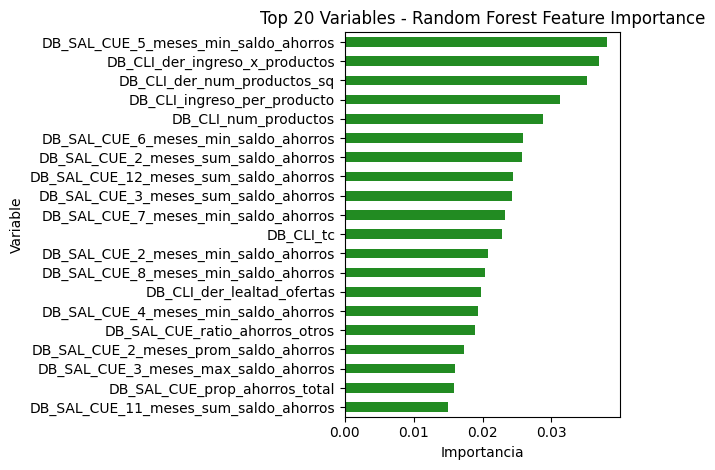


Variables seleccionadas (importancia > percentil 75): 28


In [172]:
# MÉTODO 2: Random Forest Feature Importance
from sklearn.ensemble import RandomForestClassifier

print("="*100)
print("MÉTODO 2: RANDOM FOREST FEATURE IMPORTANCE")
print("="*100)
print("\nEntrenando Random Forest...")

# Entrenar modelo
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=10)
rf.fit(X_temp, y)

# Obtener importancias
importancias = pd.DataFrame({
    'Variable': X_temp.columns,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False)

print("\nTop 20 variables más importantes según Random Forest:")
print(importancias.head(20).to_string(index=False))

# Visualizar
plt.figure(figsize=(12, 8))
importancias.head(20).plot(x='Variable', y='Importancia', kind='barh', color='forestgreen', legend=False)
plt.xlabel('Importancia')
plt.title('Top 20 Variables - Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Seleccionar variables con importancia > umbral
umbral_importancia = importancias['Importancia'].quantile(0.75)  # Top 25%
variables_rf = importancias[importancias['Importancia'] > umbral_importancia]['Variable'].tolist()
print(f"\nVariables seleccionadas (importancia > percentil 75): {len(variables_rf)}")

In [173]:
vars_seleccionadas=variables_rf

print(f"\nTotal de variables finales seleccionadas: {len(variables_rf)}")


Total de variables finales seleccionadas: 28


In [174]:
df_universo = df_universo[['ID'] + vars_seleccionadas + ['target']].copy()


In [175]:
import pandas as pd

# === FUNCIÓN PARA AGRUPAR VARIABLES CORRELACIONADAS ===
def agrupar_por_correlacion(df, umbral=0.6):
    """
    Agrupa variables numéricas del DataFrame por correlación >= umbral.
    Retorna:
        - Una lista de sets con columnas correlacionadas.
        - Un set con columnas que no se agruparon (sin correlación suficiente).
    También imprime el progreso de cuántas columnas quedan por evaluar.
    """
    df_corr = df.corr().abs()
    columnas_restantes = set(df_corr.columns)
    grupos = []
    columnas_sin_agrupacion = set()

    while columnas_restantes:
        col = next(iter(columnas_restantes))
        
        # Buscar las columnas correlacionadas dentro de las restantes
        correladas = {c for c in columnas_restantes if df_corr.loc[col, c] >= umbral}
        
        if len(correladas) > 1:
            grupos.append(correladas)
            columnas_restantes -= correladas
            print(f"✅ Nuevo set creado ({len(correladas)} columnas): {correladas}")
            print(f"➡️  Columnas restantes: {len(columnas_restantes)}\n")
        else:
            # Guardar la columna sin agrupación
            columnas_sin_agrupacion.add(col)
            columnas_restantes.remove(col)
            print(f"⚪ Columna sin correlación suficiente: {col}")
            print(f"➡️  Columnas restantes: {len(columnas_restantes)}\n")

    return grupos, columnas_sin_agrupacion


# === APLICACIÓN DIRECTA AL DATAFRAME df_limpio ===
df_numerico = df_universo.select_dtypes(include='number')
grupos_variables, columnas_sin_agrupacion = agrupar_por_correlacion(df_numerico, umbral=0.6)

# Mostrar resultados finales
print(f"\n🔹 Total de grupos encontrados: {len(grupos_variables)}\n")
for i, grupo in enumerate(grupos_variables, start=1):
    print(f"Set {i}, cantidad columnas: {len(grupo)}: {grupo}")

print(f"\n⚪ Total de columnas sin agrupación: {len(columnas_sin_agrupacion)}")
print(f"Columnas sin agrupación: {columnas_sin_agrupacion}")

✅ Nuevo set creado (18 columnas): {'DB_SAL_CUE_2_meses_sum_saldo_ahorros', 'DB_SAL_CUE_4_meses_min_saldo_ahorros', 'DB_SAL_CUE_6_meses_min_saldo_ahorros', 'DB_SAL_CUE_2_meses_prom_saldo_ahorros', 'DB_SAL_CUE_3_meses_sum_saldo_ahorros', 'DB_SAL_CUE_5_meses_min_saldo_ahorros', 'DB_SAL_CUE_5_meses_sum_saldo_ahorros', 'DB_SAL_CUE_7_meses_min_saldo_ahorros', 'DB_SAL_CUE_3_meses_max_saldo_ahorros', 'DB_SAL_CUE_9_meses_min_saldo_ahorros', 'DB_SAL_CUE_3_meses_min_saldo_ahorros', 'DB_SAL_CUE_2_meses_min_saldo_ahorros', 'DB_SAL_CUE_11_meses_sum_saldo_ahorros', 'DB_SAL_CUE_8_meses_min_saldo_ahorros', 'DB_SAL_CUE_7_meses_sum_saldo_ahorros', 'DB_SAL_CUE_10_meses_sum_saldo_ahorros', 'DB_SAL_CUE_6_meses_sum_saldo_ahorros', 'DB_SAL_CUE_12_meses_sum_saldo_ahorros'}
➡️  Columnas restantes: 10

✅ Nuevo set creado (7 columnas): {'DB_CLI_relacion_ofertas_uso', 'DB_CLI_der_lealtad_ofertas', 'DB_CLI_usa_tc_y_ahorro', 'DB_CLI_der_num_productos_sq', 'DB_CLI_num_productos', 'DB_CLI_ingreso_per_producto', 'DB_CL

In [176]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd

target = 'target'  # tu variable objetivo
X_total = df_universo
y_total = df_universo[target]

# === SELECCIÓN DE TOP 1 VARIABLE POR AUC DE CADA GRUPŌ (USANDO RANDOM FOREST) ===
variables_seleccionadas = set()

print("="*100)
print("Seleccionando la mejor variable de cada grupo usando Random Forest y AUC...")
print("="*100)

for i, grupo in enumerate(grupos_variables, start=1):
    resultados = []
    
    # Define el modelo RF ligero una vez
    model = RandomForestClassifier(
        n_estimators=50,       # Menos árboles para velocidad
        max_depth=5,           # Poca profundidad para evitar overfitting a una sola variable
        random_state=42, 
        class_weight='balanced',
        n_jobs=-1              # Usar todos los cores
    )

    for var in grupo:
        X = X_total[[var]]
        y = y_total

        # Entrenar el modelo univariado
        model.fit(X, y)
        y_pred_prob = model.predict_proba(X)
        
        # Calcular AUC multiclase
        auc = roc_auc_score(y, y_pred_prob, multi_class='ovr')
        resultados.append((var, auc))

    # Ordenar por AUC y seleccionar la mejor variable
    resultados_df = pd.DataFrame(resultados, columns=['variable','AUC']).sort_values(by='AUC', ascending=False)
    top1 = resultados_df.iloc[0]['variable']
    variables_seleccionadas.add(top1)

    print(f"\n📌 Grupo {i+1}/{len(grupos_variables)} - Variable seleccionada: {top1} (AUC: {resultados_df.iloc[0]['AUC']:.4f})")
    # print(resultados_df.to_string(index=False)) # Descomentar para ver el ranking completo de cada grupo

# === COMBINAR RESULTADOS ===
print("\n" + "="*100)
print("CONSTRUYENDO EL CONJUNTO FINAL DE VARIABLES")
print("="*100)

# Unimos las variables "campeonas" de cada grupo CON las que no tenían grupo (información única)
variables_finales = variables_seleccionadas.union(columnas_sin_agrupacion)

print(f"\n⚪ Columnas sin agrupación (únicas): {len(columnas_sin_agrupacion)}")
print(f"✅ Variables 'campeonas' de cada grupo: {len(variables_seleccionadas)}")
print("-" * 50)
print(f"➡️ Total de variables finales para el modelo: {len(variables_finales)}")
print("\nListado final de variables:")
print(sorted(list(variables_finales)))
print("="*100)

Seleccionando la mejor variable de cada grupo usando Random Forest y AUC...

📌 Grupo 2/3 - Variable seleccionada: DB_SAL_CUE_3_meses_sum_saldo_ahorros (AUC: 0.7422)

📌 Grupo 3/3 - Variable seleccionada: DB_CLI_der_ingreso_x_productos (AUC: 0.6933)

📌 Grupo 4/3 - Variable seleccionada: DB_SAL_CUE_ratio_ahorros_otros (AUC: 0.7207)

CONSTRUYENDO EL CONJUNTO FINAL DE VARIABLES

⚪ Columnas sin agrupación (únicas): 1
✅ Variables 'campeonas' de cada grupo: 3
--------------------------------------------------
➡️ Total de variables finales para el modelo: 4

Listado final de variables:
['DB_CLI_der_ingreso_x_productos', 'DB_SAL_CUE_3_meses_sum_saldo_ahorros', 'DB_SAL_CUE_ratio_ahorros_otros', 'target']


In [177]:
variables_finales.discard('target')

In [178]:
print("\nListado final de variables:")
print(sorted(list(variables_finales)))



Listado final de variables:
['DB_CLI_der_ingreso_x_productos', 'DB_SAL_CUE_3_meses_sum_saldo_ahorros', 'DB_SAL_CUE_ratio_ahorros_otros']


# 9. MODELADO CON RANDOM FOREST

Entrenaremos un modelo Random Forest usando las variables seleccionadas y evaluaremos su dese si

In [179]:
# Preparar datos para el modelo usando solo las variables seleccionadas
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("="*100)
print("PREPARACIÓN DE DATOS PARA MODELADO")
print("="*100)

# Filtrar df_encoded para usar solo las variables seleccionadas finalmente
# Las variables seleccionadas son las originales, pero después de la codificación
# pueden tener nombres diferentes (ej: one-hot crea múltiples columnas)

features = list(variables_finales)  # Convertimos el set a lista

# Crear X final con solo las columnas seleccionadas
X_final = df_universo[features]
y_final = df_universo['target']

print(f"\nShape de X_final: {X_final.shape}")
print(f"Shape de y_final: {y_final.shape}")

# Verificar distribución del target
print(f"\nDistribución del target:")
print(y_final.value_counts().sort_index())
print(f"\nDistribución porcentual:")
print((y_final.value_counts(normalize=True).sort_index() * 100).round(2))

print("="*100)

PREPARACIÓN DE DATOS PARA MODELADO

Shape de X_final: (535943, 3)
Shape de y_final: (535943,)

Distribución del target:
target
0    464075
1     47171
2      5929
3      3386
4      6893
5      8489
Name: count, dtype: int64

Distribución porcentual:
target
0    86.59
1     8.80
2     1.11
3     0.63
4     1.29
5     1.58
Name: proportion, dtype: float64


In [180]:
# Split train/test/validation
print("="*100)
print("DIVISIÓN TRAIN/TEST/VALIDATION")
print("="*100)

# Primera división: 70% train, 30% temp (test + validation)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_final, 
    y_final, 
    test_size=0.3, 
    random_state=42, 
    stratify=y_final
)

# Segunda división: De ese 30%, dividir en 20% test y 10% validation
# 20/(20+10) = 0.6667 de X_temp será test, 0.3333 será validation
X_test, X_val, y_test, y_val = train_test_split(
    X_temp, 
    y_temp, 
    test_size=0.3333,  # 10% del total / 30% del temp = 0.3333
    random_state=42, 
    stratify=y_temp
)

print(f"\nTamaño del conjunto de ENTRENAMIENTO: {X_train.shape[0]:,} ({(X_train.shape[0]/len(X_final)*100):.1f}%)")
print(f"Tamaño del conjunto de PRUEBA:        {X_test.shape[0]:,} ({(X_test.shape[0]/len(X_final)*100):.1f}%)")
print(f"Tamaño del conjunto de VALIDACIÓN:    {X_val.shape[0]:,} ({(X_val.shape[0]/len(X_final)*100):.1f}%)")
print(f"Total:                                {X_train.shape[0] + X_test.shape[0] + X_val.shape[0]:,}")

print(f"\nDistribución del target en TRAIN:")
print(y_train.value_counts(normalize=True).sort_index() * 100)

print(f"\nDistribución del target en TEST:")
print(y_test.value_counts(normalize=True).sort_index() * 100)

print(f"\nDistribución del target en VALIDATION:")
print(y_val.value_counts(normalize=True).sort_index() * 100)

print("="*100)

DIVISIÓN TRAIN/TEST/VALIDATION

Tamaño del conjunto de ENTRENAMIENTO: 375,160 (70.0%)
Tamaño del conjunto de PRUEBA:        107,194 (20.0%)
Tamaño del conjunto de VALIDACIÓN:    53,589 (10.0%)
Total:                                535,943

Distribución del target en TRAIN:
target
0    86.590521
1     8.801578
2     1.106195
3     0.631730
4     1.286118
5     1.583858
Name: proportion, dtype: float64

Distribución del target en TEST:
target
0    86.589735
1     8.801799
2     1.106405
3     0.631565
4     1.286453
5     1.584044
Name: proportion, dtype: float64

Distribución del target en VALIDATION:
target
0    86.590532
1     8.800313
2     1.106570
3     0.632593
4     1.285712
5     1.584280
Name: proportion, dtype: float64


In [181]:
# Entrenar Random Forest
print("="*100)
print("ENTRENAMIENTO DEL MODELO RANDOM FOREST")
print("="*100)

print("\nEntrenando Random Forest...")
print("  Parámetros:")
print("    - n_estimators: 100")
print("    - max_depth: 15")
print("    - min_samples_split: 10")
print("    - min_samples_leaf: 5")
print("    - random_state: 42")
print("    - n_jobs: -1 (todos los cores)")
print("    - class_weight: balanced (para manejar desbalance)")

#Entrenar modelo
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
    verbose=0# 
)

rf_model.fit(X_train, y_train)

print("\n✓ Modelo entrenado exitosamente")

# Predicciones para los 3 conjuntos
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)
y_pred_val = rf_model.predict(X_val)

# Accuracy
train_accuracy = (y_pred_train == y_train).mean()
test_accuracy = (y_pred_test == y_test).mean()
val_accuracy = (y_pred_val == y_val).mean()

print(f"\nAccuracy en TRAIN:      {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Accuracy en TEST:       {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Accuracy en VALIDATION: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")

print("="*100)

ENTRENAMIENTO DEL MODELO RANDOM FOREST

Entrenando Random Forest...
  Parámetros:
    - n_estimators: 100
    - max_depth: 15
    - min_samples_split: 10
    - min_samples_leaf: 5
    - random_state: 42
    - n_jobs: -1 (todos los cores)
    - class_weight: balanced (para manejar desbalance)

✓ Modelo entrenado exitosamente

Accuracy en TRAIN:      0.5810 (58.10%)
Accuracy en TEST:       0.5504 (55.04%)
Accuracy en VALIDATION: 0.5495 (54.95%)


In [182]:
# Métricas detalladas por categoría - CONJUNTO DE ENTRENAMIENTO
print("="*100)
print("MÉTRICAS DETALLADAS POR CATEGORÍA - CONJUNTO DE ENTRENAMIENTO")
print("="*100)

print("\nClassification Report - TRAIN:")
print("-"*100)
print(classification_report(y_train, y_pred_train, digits=4))

print("\nMatriz de Confusión - TRAIN:")
print("-"*100)
cm_train = confusion_matrix(y_train, y_pred_train)
print(cm_train)

# Crear DataFrame para mejor visualización
import pandas as pd
cm_train_df = pd.DataFrame(
    cm_train,
    index=[f"Real_{i}" for i in sorted(y_train.unique())],
    columns=[f"Pred_{i}" for i in sorted(y_train.unique())]
)
print("\nMatriz de Confusión (formato tabla) - TRAIN:")
print(cm_train_df)

print("="*100)

MÉTRICAS DETALLADAS POR CATEGORÍA - CONJUNTO DE ENTRENAMIENTO

Classification Report - TRAIN:
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9740    0.5529    0.7054    324853
           1     0.2447    0.7667    0.3710     33020
           2     0.1166    0.9186    0.2070      4150
           3     0.1149    0.8641    0.2028      2370
           4     0.2081    0.6945    0.3203      4825
           5     0.1862    0.6488    0.2893      5942

    accuracy                         0.5810    375160
   macro avg     0.3074    0.7409    0.3493    375160
weighted avg     0.8726    0.5810    0.6557    375160


Matriz de Confusión - TRAIN:
----------------------------------------------------------------------------------------------------
[[179595  77013  26749  14705  10504  16287]
 [  4338  25317    324    697   1960    384]
 [    14     50   3812     30    127    1

In [183]:
# Métricas detalladas por categoría - CONJUNTO DE PRUEBA
print("="*100)
print("MÉTRICAS DETALLADAS POR CATEGORÍA - CONJUNTO DE PRUEBA")
print("="*100)

print("\nClassification Report - TEST:")
print("-"*100)
print(classification_report(y_test, y_pred_test, digits=4))

print("\nMatriz de Confusión - TEST:")
print("-"*100)
cm_test = confusion_matrix(y_test, y_pred_test)
print(cm_test)

# Crear DataFrame para mejor visualización
cm_test_df = pd.DataFrame(
    cm_test,
    index=[f"Real_{i}" for i in sorted(y_test.unique())],
    columns=[f"Pred_{i}" for i in sorted(y_test.unique())]
)
print("\nMatriz de Confusión (formato tabla) - TEST:")
print(cm_test_df)

print("="*100)

MÉTRICAS DETALLADAS POR CATEGORÍA - CONJUNTO DE PRUEBA

Classification Report - TEST:
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9519    0.5406    0.6895     92819
           1     0.2234    0.7060    0.3394      9435
           2     0.0874    0.6872    0.1551      1186
           3     0.0446    0.3250    0.0785       677
           4     0.1357    0.4496    0.2084      1379
           5     0.0865    0.2980    0.1341      1698

    accuracy                         0.5504    107194
   macro avg     0.2549    0.5010    0.2675    107194
weighted avg     0.8483    0.5504    0.6340    107194


Matriz de Confusión - TEST:
----------------------------------------------------------------------------------------------------
[[50174 22511  7676  4323  3156  4979]
 [ 1753  6661   101   182   642    96]
 [   44    53   815    13    85   176]
 [  197   141    17   2

In [184]:
# Métricas detalladas por categoría - CONJUNTO DE VALIDACIÓN
print("="*100)
print("MÉTRICAS DETALLADAS POR CATEGORÍA - CONJUNTO DE VALIDACIÓN")
print("="*100)

print("\nClassification Report - VALIDATION:")
print("-"*100)
print(classification_report(y_val, y_pred_val, digits=4))

print("\nMatriz de Confusión - VALIDATION:")
print("-"*100)
cm_val = confusion_matrix(y_val, y_pred_val)
print(cm_val)

# Crear DataFrame para mejor visualización
cm_val_df = pd.DataFrame(
    cm_val,
    index=[f"Real_{i}" for i in sorted(y_val.unique())],
    columns=[f"Pred_{i}" for i in sorted(y_val.unique())]
)
print("\nMatriz de Confusión (formato tabla) - VALIDATION:")
print(cm_val_df)

print("="*100)

MÉTRICAS DETALLADAS POR CATEGORÍA - CONJUNTO DE VALIDACIÓN

Classification Report - VALIDATION:
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9493    0.5410    0.6892     46403
           1     0.2200    0.6974    0.3345      4716
           2     0.0869    0.6728    0.1539       593
           3     0.0439    0.3156    0.0771       339
           4     0.1440    0.4572    0.2190       689
           5     0.0779    0.2733    0.1213       849

    accuracy                         0.5495     53589
   macro avg     0.2537    0.4929    0.2658     53589
weighted avg     0.8457    0.5495    0.6332     53589


Matriz de Confusión - VALIDATION:
----------------------------------------------------------------------------------------------------
[[25104 11340  3781  2129  1499  2550]
 [  911  3289    65    99   296    56]
 [   29    22   399    13    31    99]
 [  107

VISUALIZACIÓN DE MATRICES DE CONFUSIÓN


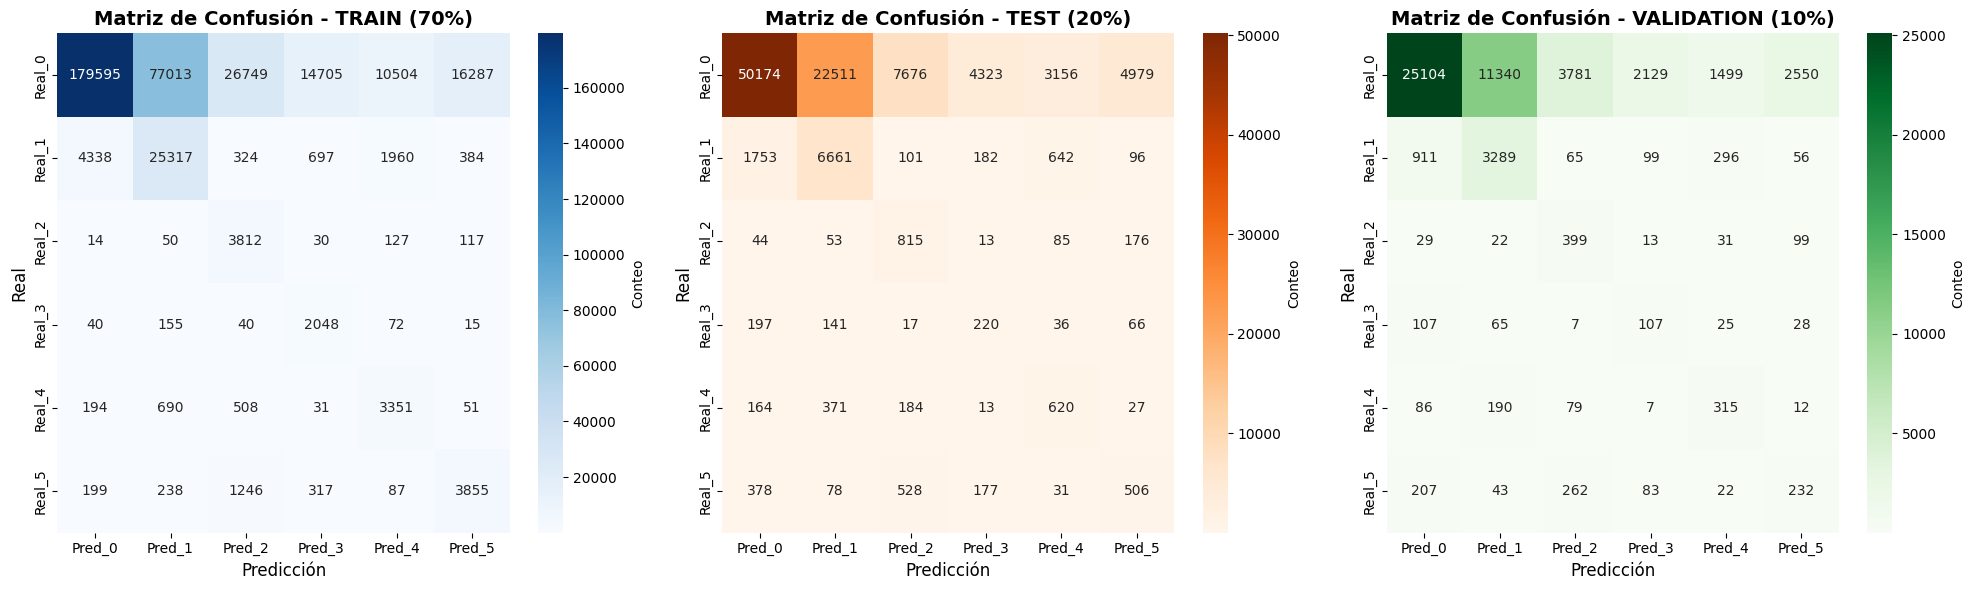

In [185]:
# Visualización de las matrices de confusión
print("="*100)
print("VISUALIZACIÓN DE MATRICES DE CONFUSIÓN")
print("="*100)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Matriz de confusión - TRAIN
sns.heatmap(cm_train_df, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar_kws={'label': 'Conteo'})
axes[0].set_title('Matriz de Confusión - TRAIN (70%)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicción', fontsize=12)
axes[0].set_ylabel('Real', fontsize=12)

# Matriz de confusión - TEST
sns.heatmap(cm_test_df, annot=True, fmt='d', cmap='Oranges', ax=axes[1], cbar_kws={'label': 'Conteo'})
axes[1].set_title('Matriz de Confusión - TEST (20%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicción', fontsize=12)
axes[1].set_ylabel('Real', fontsize=12)

# Matriz de confusión - VALIDATION
sns.heatmap(cm_val_df, annot=True, fmt='d', cmap='Greens', ax=axes[2], cbar_kws={'label': 'Conteo'})
axes[2].set_title('Matriz de Confusión - VALIDATION (10%)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Predicción', fontsize=12)
axes[2].set_ylabel('Real', fontsize=12)

plt.tight_layout()
plt.show()

print("="*100)

In [186]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
import numpy as np

# Distribución de clases
counts = {
    0: 464075,
    1: 47171,
    2: 5929,
    3: 3386,
    4: 6893,
    5: 8489
}

# Pesos base de 'balanced'
total = sum(counts.values())
n_classes = len(counts)
weights_balanced = {cls: total / (n_classes * n_i) for cls, n_i in counts.items()}

print("Pesos base (balanced):")
for k, v in weights_balanced.items():
    print(f"Clase {k}: {v:.4f}")

# Monte Carlo
n_iter = 50  # puedes subirlo a 100 o 200 si tienes tiempo
best_f1 = 0
best_weights = None

print("\n🔍 Buscando pesos óptimos (Monte Carlo multiclase)...\n")

for i in range(n_iter):
    # Generamos pequeñas perturbaciones aleatorias a cada peso
    random_weights = {
        cls: w * np.random.uniform(0.5, 2.0)  # variar entre 50% y 200% del valor base
        for cls, w in weights_balanced.items()
    }

    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
        class_weight=random_weights,
        verbose=0
    )

    rf.fit(X_train, y_train)
    y_pred_val = rf.predict(X_val)
    f1 = f1_score(y_val, y_pred_val, average='macro')  # promedio simple entre clases

    if f1 > best_f1:
        best_f1 = f1
        best_weights = random_weights

    print(f"Iteración {i+1}/{n_iter} -> F1-macro = {f1:.4f}")

print("\n===========================================================")
print(f"✅ Mejor F1-macro: {best_f1:.4f}")
print("✅ Pesos óptimos encontrados:")
for k, v in best_weights.items():
    print(f"Clase {k}: {v:.4f}")
print("===========================================================")


Pesos base (balanced):
Clase 0: 0.1925
Clase 1: 1.8936
Clase 2: 15.0656
Clase 3: 26.3803
Clase 4: 12.9586
Clase 5: 10.5223

🔍 Buscando pesos óptimos (Monte Carlo multiclase)...

Iteración 1/50 -> F1-macro = 0.2657
Iteración 2/50 -> F1-macro = 0.2772
Iteración 3/50 -> F1-macro = 0.2636
Iteración 4/50 -> F1-macro = 0.2200
Iteración 5/50 -> F1-macro = 0.2870
Iteración 6/50 -> F1-macro = 0.2464
Iteración 7/50 -> F1-macro = 0.2809
Iteración 8/50 -> F1-macro = 0.2261
Iteración 9/50 -> F1-macro = 0.2732
Iteración 10/50 -> F1-macro = 0.2715
Iteración 11/50 -> F1-macro = 0.2320
Iteración 12/50 -> F1-macro = 0.2659
Iteración 13/50 -> F1-macro = 0.2599
Iteración 14/50 -> F1-macro = 0.2627
Iteración 15/50 -> F1-macro = 0.3098
Iteración 16/50 -> F1-macro = 0.2603
Iteración 17/50 -> F1-macro = 0.2676
Iteración 18/50 -> F1-macro = 0.2531
Iteración 19/50 -> F1-macro = 0.2569
Iteración 20/50 -> F1-macro = 0.2566
Iteración 21/50 -> F1-macro = 0.2702
Iteración 22/50 -> F1-macro = 0.2645
Iteración 23/50 -

In [187]:
print("\n===========================================================")
print(f" Mejor F1-macro: {best_f1:.4f}")
print(" Pesos óptimos encontrados:")
for k, v in best_weights.items():
    print(f"Clase {k}: {v:.4f}")
print("===========================================================")


 Mejor F1-macro: 0.3098
 Pesos óptimos encontrados:
Clase 0: 0.3780
Clase 1: 2.0122
Clase 2: 20.2087
Clase 3: 23.4716
Clase 4: 6.9554
Clase 5: 11.2008


In [188]:
rf_final = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    class_weight=best_weights
)

rf_final.fit(X_train, y_train)

# Predicciones para los 3 conjuntos
y_pred_train2 = rf_final.predict(X_train)
y_pred_test2 = rf_final.predict(X_test)
y_pred_val2 = rf_final.predict(X_val)

# Accuracy
train_accuracy = (y_pred_train2 == y_train).mean()
test_accuracy = (y_pred_test2 == y_test).mean()
val_accuracy = (y_pred_val2 == y_val).mean()

print(f"\nAccuracy en TRAIN:      {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Accuracy en TEST:       {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Accuracy en VALIDATION: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")

print("="*100)



Accuracy en TRAIN:      0.7047 (70.47%)
Accuracy en TEST:       0.6755 (67.55%)
Accuracy en VALIDATION: 0.6755 (67.55%)


In [189]:
# Métricas detalladas por categoría - CONJUNTO DE ENTRENAMIENTO
print("="*100)
print("MÉTRICAS DETALLADAS POR CATEGORÍA - CONJUNTO DE ENTRENAMIENTO")
print("="*100)

print("\nClassification Report - TRAIN:")
print("-"*100)
print(classification_report(y_train, y_pred_train2, digits=4))

print("\nMatriz de Confusión - TRAIN:")
print("-"*100)
cm_train = confusion_matrix(y_train, y_pred_train2)
print(cm_train)

# Crear DataFrame para mejor visualización
import pandas as pd
cm_train_df = pd.DataFrame(
    cm_train,
    index=[f"Real_{i}" for i in sorted(y_train.unique())],
    columns=[f"Pred_{i}" for i in sorted(y_train.unique())]
)
print("\nMatriz de Confusión (formato tabla) - TRAIN:")
print(cm_train_df)

print("="*100)







MÉTRICAS DETALLADAS POR CATEGORÍA - CONJUNTO DE ENTRENAMIENTO

Classification Report - TRAIN:
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9526    0.7144    0.8165    324853
           1     0.3177    0.6347    0.4234     33020
           2     0.1079    0.9470    0.1937      4150
           3     0.2028    0.7890    0.3227      2370
           4     0.3552    0.4844    0.4099      4825
           5     0.2401    0.5382    0.3321      5942

    accuracy                         0.7047    375160
   macro avg     0.3627    0.6846    0.4164    375160
weighted avg     0.8636    0.7047    0.7590    375160


Matriz de Confusión - TRAIN:
----------------------------------------------------------------------------------------------------
[[232089  43752  29625   6694   2947   9746]
 [  9901  20957    418    383   1113    248]
 [    35     32   3930     14     85     

In [190]:
# Métricas detalladas por categoría - CONJUNTO DE PRUEBA
print("="*100)
print("MÉTRICAS DETALLADAS POR CATEGORÍA - CONJUNTO DE PRUEBA")
print("="*100)

print("\nClassification Report - TEST:")
print("-"*100)
print(classification_report(y_test, y_pred_test2, digits=4))

print("\nMatriz de Confusión - TEST:")
print("-"*100)
cm_test = confusion_matrix(y_test, y_pred_test2)
print(cm_test)

# Crear DataFrame para mejor visualización
cm_test_df = pd.DataFrame(
    cm_test,
    index=[f"Real_{i}" for i in sorted(y_test.unique())],
    columns=[f"Pred_{i}" for i in sorted(y_test.unique())]
)
print("\nMatriz de Confusión (formato tabla) - TEST:")
print(cm_test_df)

print("="*100)

MÉTRICAS DETALLADAS POR CATEGORÍA - CONJUNTO DE PRUEBA

Classification Report - TEST:
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9315    0.7035    0.8016     92819
           1     0.2773    0.5530    0.3694      9435
           2     0.0862    0.7546    0.1547      1186
           3     0.0613    0.2171    0.0956       677
           4     0.2657    0.3648    0.3075      1379
           5     0.0955    0.2026    0.1298      1698

    accuracy                         0.6755    107194
   macro avg     0.2863    0.4659    0.3098    107194
weighted avg     0.8373    0.6755    0.7350    107194


Matriz de Confusión - TEST:
----------------------------------------------------------------------------------------------------
[[65298 13078  8474  2036   906  3027]
 [ 3520  5218   133   108   388    68]
 [   75    47   895     6    56   107]
 [  346    97    18   1

In [191]:
# Métricas detalladas por categoría - CONJUNTO DE VALIDACIÓN
print("="*100)
print("MÉTRICAS DETALLADAS POR CATEGORÍA - CONJUNTO DE VALIDACIÓN")
print("="*100)

print("\nClassification Report - VALIDATION:")
print("-"*100)
print(classification_report(y_val, y_pred_val2, digits=4))

print("\nMatriz de Confusión - VALIDATION:")
print("-"*100)
cm_val = confusion_matrix(y_val, y_pred_val2)
print(cm_val)

# Crear DataFrame para mejor visualización
cm_val_df = pd.DataFrame(
    cm_val,
    index=[f"Real_{i}" for i in sorted(y_val.unique())],
    columns=[f"Pred_{i}" for i in sorted(y_val.unique())]
)
print("\nMatriz de Confusión (formato tabla) - VALIDATION:")
print(cm_val_df)

print("="*100)

MÉTRICAS DETALLADAS POR CATEGORÍA - CONJUNTO DE VALIDACIÓN

Classification Report - VALIDATION:
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9303    0.7040    0.8015     46403
           1     0.2776    0.5509    0.3692      4716
           2     0.0859    0.7437    0.1540       593
           3     0.0568    0.2094    0.0894       339
           4     0.2872    0.3730    0.3245       689
           5     0.0877    0.1896    0.1199       849

    accuracy                         0.6755     53589
   macro avg     0.2876    0.4618    0.3098     53589
weighted avg     0.8364    0.6755    0.7349     53589


Matriz de Confusión - VALIDATION:
----------------------------------------------------------------------------------------------------
[[32670  6489  4209  1056   433  1546]
 [ 1787  2598    74    58   165    34]
 [   47    16   441     8    14    67]
 [  168

VISUALIZACIÓN DE MATRICES DE CONFUSIÓN


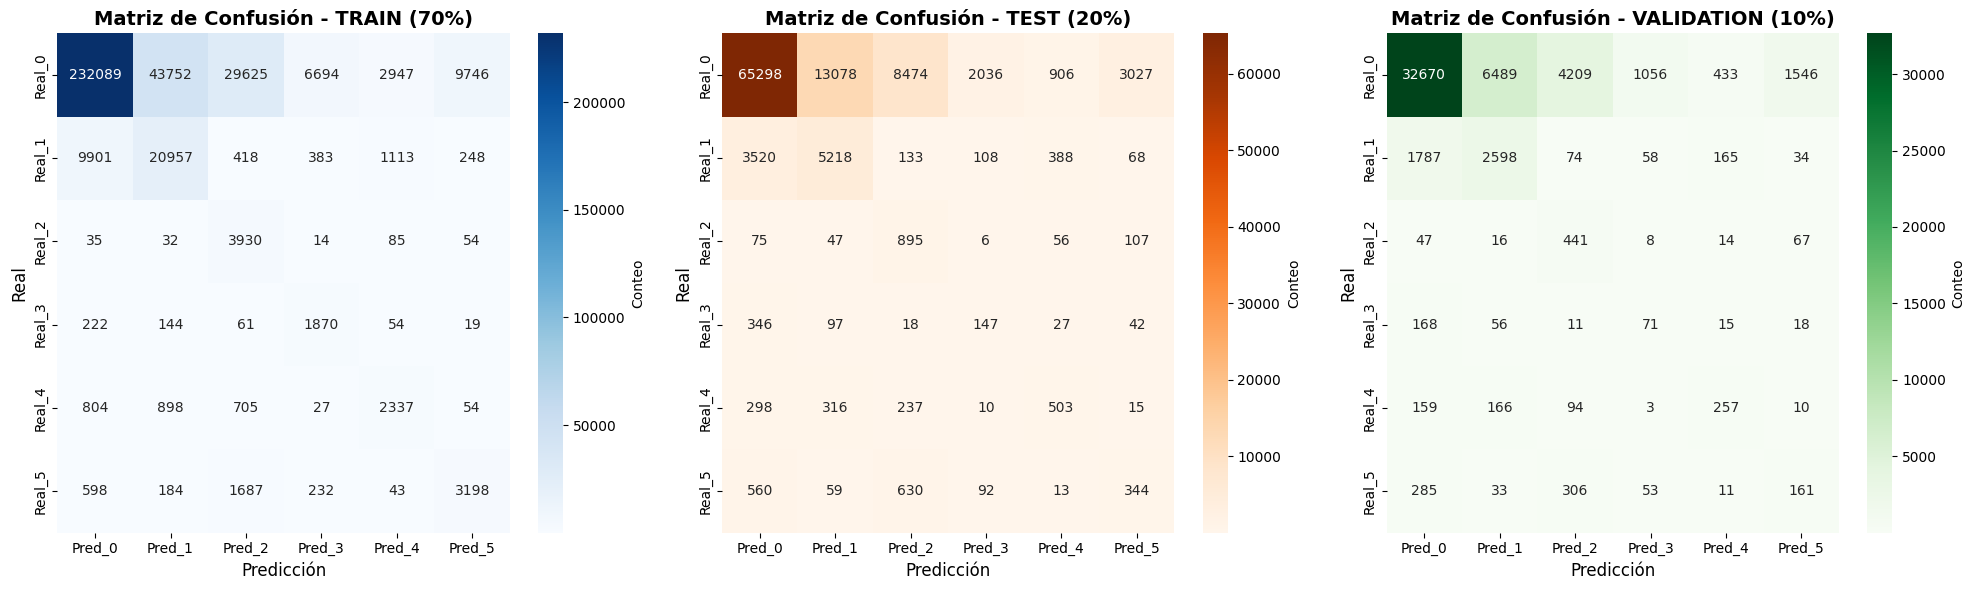

In [192]:

# Visualización de las matrices de confusión
print("="*100)
print("VISUALIZACIÓN DE MATRICES DE CONFUSIÓN")
print("="*100)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Matriz de confusión - TRAIN
sns.heatmap(cm_train_df, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar_kws={'label': 'Conteo'})
axes[0].set_title('Matriz de Confusión - TRAIN (70%)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicción', fontsize=12)
axes[0].set_ylabel('Real', fontsize=12)

# Matriz de confusión - TEST
sns.heatmap(cm_test_df, annot=True, fmt='d', cmap='Oranges', ax=axes[1], cbar_kws={'label': 'Conteo'})
axes[1].set_title('Matriz de Confusión - TEST (20%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicción', fontsize=12)
axes[1].set_ylabel('Real', fontsize=12)

# Matriz de confusión - VALIDATION
sns.heatmap(cm_val_df, annot=True, fmt='d', cmap='Greens', ax=axes[2], cbar_kws={'label': 'Conteo'})
axes[2].set_title('Matriz de Confusión - VALIDATION (10%)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Predicción', fontsize=12)
axes[2].set_ylabel('Real', fontsize=12)

plt.tight_layout()
plt.show()

print("="*100)


In [194]:
import pandas as pd
import matplotlib.pyplot as plt

# Importancia de características
importances_final = rf_final.feature_importances_

# Crear DataFrame ordenado
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances_final
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df.head(20))


                                Feature  Importance
2        DB_CLI_der_ingreso_x_productos    0.343177
1  DB_SAL_CUE_3_meses_sum_saldo_ahorros    0.336960
0        DB_SAL_CUE_ratio_ahorros_otros    0.319864


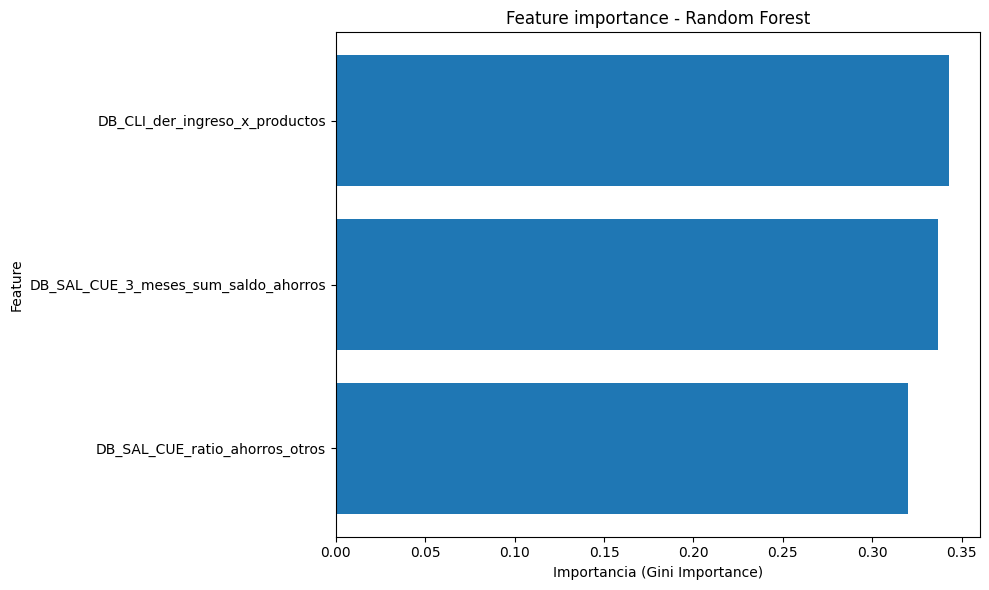

In [195]:
plt.figure(figsize=(10,6))
plt.barh(
    feature_importance_df['Feature'][:20][::-1],
    feature_importance_df['Importance'][:20][::-1]
)
plt.title("Feature importance - Random Forest")
plt.xlabel("Importancia (Gini Importance)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [196]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    rf_final, X_val, y_val, 
    n_repeats=10, random_state=42, n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)

print(perm_importance_df.head(30))


                                Feature  Importance
1  DB_SAL_CUE_3_meses_sum_saldo_ahorros    0.033018
2        DB_CLI_der_ingreso_x_productos    0.024878
0        DB_SAL_CUE_ratio_ahorros_otros    0.020687
